# 🎯 Meningioma Thresholder

Run from the repo root. Reads `output/datasets/` from the cleaning notebook, writes everything to `output/thresholds/`, and builds `threshold_report.html` at the end.

Two questions, kept apart: **where does risk start climbing** (§04, the threshold) and **where do you draw one line** (§05, the cut-point). §06 combines them, §07 checks they survive the missing scans, §08 grades how strongly each is supported.

## 00. Setup

Imports, run settings and the export sink. Nothing outside `output/thresholds/` is touched.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# ⚙️ Import config first — it prepends cleaning_phase/, modelling_phase/ and
#    threshold_phase/ to sys.path so the flat sibling imports below resolve.
from heavy_machinery.config import load  # noqa: F401
analysis = load("analysis")
from heavy_machinery.cleaning_phase.dataset_handoff import load_modelling_handoff

import plot_style as ps
import calibration as cal
import combinations as cb
import evidence as ev
import risk_curves as rc
import stability as st
import study
import thresholds as th
from artifacts import ThresholdArtifacts

pd.set_option("display.max_columns", None)
ps.apply_plot_style()  # SciencePlots (science + nature + no-latex), same as the pipeline

OUTPUT_ROOT = Path("output")
TARGET = "high_grade"
NEGATIVE_LABEL = "Benign (WHO 1)"
POSITIVE_LABEL = "High grade (WHO 2–3)"

# 🟧 None = all years; e.g. [2025] for a single cohort year.
ANALYSIS_YEARS: list[int] | None = None

# 🟧 Bootstrap replicates, sourced from the shared analysis config so the
#    report header can never claim a count that differs from what actually ran.
N_BOOTSTRAP = analysis.BOOTSTRAP_RESAMPLES
N_BOOTSTRAP_CURVE = analysis.BOOTSTRAP_RESAMPLES
BOOTSTRAP_SEED = 20260801

# 🟧 Risk levels to locate on each curve. These are the numbers a clinician
#    actually asks for — "at what volume does this become a coin flip?"
RISK_LEVELS = (0.30, 0.50)

# 🟧 Set enabled=False for a read-only run: everything still renders inline,
#    nothing reaches disk.
art = ThresholdArtifacts(
    root=OUTPUT_ROOT / "thresholds",
    enabled=True,
    context={
        "n_bootstrap": N_BOOTSTRAP,
        "n_bootstrap_curve": N_BOOTSTRAP_CURVE,
        "seed": BOOTSTRAP_SEED,
        "risk_levels": list(RISK_LEVELS),
        "analysis_years": ANALYSIS_YEARS,
    },
)
print(f"Figures → {art.figure_dir}")
print(f"Tables  → {art.table_dir}")

Figures → output/thresholds/figures
Tables  → output/thresholds/tables


## 01. Load handoff

Loads the **unimputed** cohort: §02–06 use observed values only. §07 re-runs everything on the MICE draws to see what that cost.

In [2]:
df, schema, IMPUTATION_METHOD = load_modelling_handoff(OUTPUT_ROOT, verbose=False)
print(f"Unimputed cohort: {len(df)} rows, {len(schema)} schema columns")
print(f"Imputation on the handoff: {IMPUTATION_METHOD} (observed values in §02–06, draws in §07)")

if ANALYSIS_YEARS is not None:
    df = df[df["entry_year"].isin(ANALYSIS_YEARS)].copy()
    print(f"Year filter {ANALYSIS_YEARS} → {len(df)} rows")

df.head(3)

Unimputed cohort: 352 rows, 52 schema columns
Imputation on the handoff: mice (observed values in §02–06, draws in §07)


,id,patient_code,entry_year,age,sex,who_grade,mri_date,side,tumor_location,meningioma_count,max_diameter_cm,tumor_volume,tumor_episode,tumor_margin,dural_tail,capsular_enhancement,heterogeneous_enhancement,perifocal_edema,edema_volume_cm3,mass_effect,calcification,cystic_component,mri_necrosis,hemorrhage,hyperostosis,cortical_destruction,dwi_hyperintensity,t2_hyperintensity,t1_hypointensity,sinus_invasion,transfalcine_extension,adc_value,high_grade,multiple_meningiomas,venous_sinus_invasion,male_sex,irregular_margin,skull_base_location,midline,edema_index,edema_index_ge0.0617,edema_volume_ge4.76,tumor_volume_ge15.1,max_diameter_cm_ge3.81,adc_value_le0.72
0,2,070458-11352,2025,67.0,female,1,2025-06-27,right,skull_base,2,4.9,36.5,primary,regular,False,True,False,True,5.0,True,True,False,False,False,False,False,True,True,True,no_invasion,False,0.88,False,True,False,False,False,True,False,0.136986,True,True,True,True,False
1,3,230949-11093,2025,76.0,female,1,2025-09-05,midline,skull_base,1,2.8,6.86,primary,irregular,False,True,False,True,26.0,True,False,False,False,False,False,False,True,True,True,no_invasion,True,0.94,False,False,False,False,True,True,True,3.790087,True,True,False,False,False
2,4,140352-11498,2025,73.0,female,2,2025-07-23,right,non_skull_base,1,4.7,40.9,recurrent,irregular,False,True,True,True,135.0,True,True,True,False,True,False,False,True,True,True,no_invasion,False,0.6,True,False,False,False,True,False,False,3.300733,True,True,True,True,True


## 02. Outcome and metrics

**Outcome:** `high_grade` — WHO 2–3 positive, WHO 1 negative, complete for every patient.

**Direction** is the field to get right: `"lower"` means low values are suspicious (ADC), `"higher"` means high values are (volumes).

In [3]:
def derive_edema_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Edema burden relative to tumor size. Guards against division by zero.

    Defined as a function because §07 has to recompute it *inside* every MICE
    draw, from that draw's own imputed components — imputing a ratio directly
    would not respect its two parents.
    """
    frame = frame.copy()
    tumor = frame["tumor_volume"].astype("Float64")
    frame["edema_index"] = frame["edema_volume_cm3"].astype("Float64") / tumor.where(tumor > 0)
    return frame


df = derive_edema_index(df)

# Candidates for the fill-in cell below: every numeric column, with how many
# patients actually have it. A column measured in 40 patients cannot carry a
# threshold no matter how good it looks.
candidates = pd.DataFrame({
    "n_measured": df.select_dtypes("number").notna().sum(),
    "median": df.select_dtypes("number").median(numeric_only=True).round(2),
}).sort_values("n_measured", ascending=False)
print(f"{len(candidates)} numeric columns — pick from these:")
display(candidates.head(20))

8 numeric columns — pick from these:


,n_measured,median
entry_year,352,2023.0
age,352,65.0
meningioma_count,352,1.0
max_diameter_cm,352,3.8
edema_volume_cm3,333,4.48
tumor_volume,329,14.7
edema_index,323,0.22
adc_value,309,0.82


### 🟧 Fill in — which columns to search a threshold for

One `Metric` per numeric column. This list drives the whole notebook and the whole threshold report; a different study edits this cell and nothing else.

**`direction` is the field to get right:** `"lower"` means low values point at the outcome, `"higher"` means high values do. Wrong direction gives plausible numbers pointing the wrong way, and nothing downstream can detect it.

In [4]:
# 🟧 FILL IN — the continuous measurements a cut-point is searched for.
#    Add a row and it gets a cut-point, a risk curve, a bootstrap interval and
#    its own paragraph in the report; delete a row and all of that goes.
#
#      col         column name in `df` — pick from the candidate table above
#      label       how it is named in every figure and sentence
#      unit        for axis labels; matplotlib mathtext allowed
#      direction   "lower" / "higher" — which end points at the outcome
#      log_x       True for right-skewed measurements, e.g. volumes
#      unit_plain  unit as it reads in a sentence; "" if there is none
#
#    A mistyped `col` is dropped silently — check the count printed below.
METRICS = th.validate_metrics([
    th.Metric("adc_value", "ADC (mean)", r"$\times 10^{-3}$ mm$^2$/s", "lower",
              unit_plain="×10⁻³ mm²/s"),
    # cc and cm³ are the same unit; cm³ is what the source column and the
    # published cut-points use, so it is what the axes and the prose say.
    th.Metric("tumor_volume", "Tumor volume", "cm$^3$", "higher", log_x=True,
              unit_plain="cm³"),
    th.Metric("edema_volume_cm3", "Edema volume", "cm$^3$", "higher", log_x=True,
              unit_plain="cm³"),
    th.Metric("edema_index", "Edema index", "edema ÷ tumor", "higher", log_x=True,
              unit_plain=""),
    # The only measurement with published cut-points derived against WHO grade
    # itself (Magill 2018).
    th.Metric("max_diameter_cm", "Max diameter", "cm", "higher"),
], df)

print(f"{len(METRICS)} metrics: " + ", ".join(f"{m.label} ({m.op})" for m in METRICS))

5 metrics: ADC (mean) (≤), Tumor volume (≥), Edema volume (≥), Edema index (≥), Max diameter (≥)


### 🟧 Fill in — published cut-points to test against this cohort

Each one is scored on our patients without any optimism correction: it was not estimated here, which is what makes *validating* an external cut-point a stronger design than deriving one. The link travels with the number so a reviewer can check it in one click.

In [5]:
# 🟧 Published cut-points, from the four comparison tables. Only rows that gave
#    a number are here: "continuous OR only" (Spille 2021), post-operative
#    residual volume, the ">5–6 cm giant" naming convention and the
#    resection-dependent RPA splits are not cut-points this cohort can validate.
#
#    The outcome each one was derived against is part of the label — only
#    Magill's were fitted against WHO grade itself, and nobody should read the
#    others as grade thresholds.
LITERATURE_CUTOFFS: dict[str, list[tuple[float, str]]] = {
    "edema_index": [
        (1.0, "Frati, Armocida et al., Tomography 2022;8(4):1987–1996 (recurrence)"),
        (2.01, "Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 "
               "(KPS decline, ≥60 y; range low)"),
        (3.37, "Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 "
               "(KPS decline, ≥60 y; range high)"),
    ],
    "edema_volume_cm3": [
        (3.64, "Adeli, Spille et al., Oncotarget 2018;9(89):35974–35982 "
               "(brain invasion)"),
    ],
    "tumor_volume": [
        (13.95, "Shin, Kim, Cheong et al., PLoS One 2021;16(6):e0252945 "
                "(edema presence)"),
        (26.4, "Recurrence in atypical meningioma, PMID 37867351 (3-year recurrence)"),
    ],
    "max_diameter_cm": [
        (3.0, "Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 "
              "(WHO grade II, OR 1.69)"),
        (6.0, "Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 "
              "(WHO grade II, OR 3.01)"),
        (6.05, "Advanced-MRI series, n=27, PMC9634949 (atypical histology)"),
    ],
    # 🟧 No published ADC cut-point yet — ours has nothing to be validated
    #    against, which is the weakest point in the ADC finding.
}

# 🟧 {source: url}. Only identifiers the sources actually carry — a guessed DOI
#    is worse than a missing one, so a paper without one is left unlinked.
LITERATURE_LINKS: dict[str, str] = {
    "Frati, Armocida et al., Tomography 2022;8(4):1987–1996 (recurrence)":
        "https://doi.org/10.3390/tomography8040166",
    "Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 "
    "(KPS decline, ≥60 y; range low)":
        "https://doi.org/10.1093/ons/opy107",
    "Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 "
    "(KPS decline, ≥60 y; range high)":
        "https://doi.org/10.1093/ons/opy107",
    "Shin, Kim, Cheong et al., PLoS One 2021;16(6):e0252945 (edema presence)":
        "https://doi.org/10.1371/journal.pone.0252945",
    "Recurrence in atypical meningioma, PMID 37867351 (3-year recurrence)":
        "https://pubmed.ncbi.nlm.nih.gov/37867351/",
    "Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 (WHO grade II, OR 1.69)":
        "https://doi.org/10.3171/2018.1.FOCUS17752",
    "Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 (WHO grade II, OR 3.01)":
        "https://doi.org/10.3171/2018.1.FOCUS17752",
    "Advanced-MRI series, n=27, PMC9634949 (atypical histology)":
        "https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9634949/",
    # Adeli 2018: no DOI or PMID in the source table, so no link is invented.
}

art.table(study.literature_sources_table(LITERATURE_CUTOFFS, LITERATURE_LINKS),
          "47_literature_sources", formatted=False,
          caption="Published cut-points scored on this cohort, with their sources")

,column,cutoff,source,link
0,edema_index,1.00,"Frati, Armocida et al., Tomography 2022;8(4):1...",https://doi.org/10.3390/tomography8040166
1,edema_index,2.01,"Loewenstern et al., Oper Neurosurg 2019;16(3):...",https://doi.org/10.1093/ons/opy107
2,edema_index,3.37,"Loewenstern et al., Oper Neurosurg 2019;16(3):...",https://doi.org/10.1093/ons/opy107
3,edema_volume_cm3,3.64,"Adeli, Spille et al., Oncotarget 2018;9(89):35...",
4,tumor_volume,13.95,"Shin, Kim, Cheong et al., PLoS One 2021;16(6):...",https://doi.org/10.1371/journal.pone.0252945
5,tumor_volume,26.40,"Recurrence in atypical meningioma, PMID 378673...",https://pubmed.ncbi.nlm.nih.gov/37867351/
6,max_diameter_cm,3.00,"Magill, Young, Chae et al., Neurosurg Focus 20...",https://doi.org/10.3171/2018.1.FOCUS17752
7,max_diameter_cm,6.00,"Magill, Young, Chae et al., Neurosurg Focus 20...",https://doi.org/10.3171/2018.1.FOCUS17752
8,max_diameter_cm,6.05,"Advanced-MRI series, n=27, PMC9634949 (atypica...",https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9...


💾 output/thresholds/tables/47_literature_sources.csv — 9 rows


,column,cutoff,source,link
0,edema_index,1.00,"Frati, Armocida et al., Tomography 2022;8(4):1...",https://doi.org/10.3390/tomography8040166
1,edema_index,2.01,"Loewenstern et al., Oper Neurosurg 2019;16(3):...",https://doi.org/10.1093/ons/opy107
2,edema_index,3.37,"Loewenstern et al., Oper Neurosurg 2019;16(3):...",https://doi.org/10.1093/ons/opy107
3,edema_volume_cm3,3.64,"Adeli, Spille et al., Oncotarget 2018;9(89):35...",
4,tumor_volume,13.95,"Shin, Kim, Cheong et al., PLoS One 2021;16(6):...",https://doi.org/10.1371/journal.pone.0252945
5,tumor_volume,26.40,"Recurrence in atypical meningioma, PMID 378673...",https://pubmed.ncbi.nlm.nih.gov/37867351/
6,max_diameter_cm,3.00,"Magill, Young, Chae et al., Neurosurg Focus 20...",https://doi.org/10.3171/2018.1.FOCUS17752
7,max_diameter_cm,6.00,"Magill, Young, Chae et al., Neurosurg Focus 20...",https://doi.org/10.3171/2018.1.FOCUS17752
8,max_diameter_cm,6.05,"Advanced-MRI series, n=27, PMC9634949 (atypica...",https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9...


### 🟧 Fill in — the four facts the images cannot tell us

Everything else a reviewer asks about the methods is read back out of the cleaning run below (WHO edition, the filters that built the cohort, where each derived measurement comes from). These four are not in any file, and each one decides whether a number in this analysis transfers outside this hospital. Leave a string empty and it stays an open question in the report rather than becoming a plausible-looking guess.

In [6]:
# 🟧 Answer what you can; blanks stay visible as open questions.
STUDY_FACTS: dict[str, str] = {
    # Why it matters: the grade is the reference standard everything is measured
    # against. If it was read with the MRI in view, the design is circular.
    "histology_reading": "",

    # Why it matters: ADC values are not comparable between b-value schemes, so
    # without this our ADC cut-point cannot be used or checked by anyone else.
    "dwi_acquisition": "",

    # Why it matters: single-slice and whole-tumour ADC differ systematically —
    # the leading explanation for published ADC cut-points not reproducing.
    "adc_roi": "",

    # Why it matters: both volume cut-points are quoted in cc against published
    # ones, and they are only comparable if the segmentation is.
    "volumetry": "",
}

STUDY_TABLE = study.study_facts_table(STUDY_FACTS, OUTPUT_ROOT)
art.table(STUDY_TABLE, "46_study_facts", formatted=False,
          caption="Methods facts: read from the cleaning run, or still open")

open_now = study.open_questions(STUDY_TABLE)
print(f"✅ {len(STUDY_TABLE) - len(open_now)} answered from the pipeline · "
      f"🟧 {len(open_now)} still open")
for _, row in open_now.iterrows():
    print(f"   🟧 {row['item']}: {row['answer']}")

,key,item,answer,status,why
0,who_edition,Outcome and WHO edition,WHO 2021 CNS classification: grade 2/3 = high-...,answered from the data,A high-grade rate cannot be interpreted withou...
1,edema_index,Definition of the edema index,"Edema volume (cc) ÷ tumour volume (cc), left m...",answered from the data,The index is analysed throughout and is define...
2,published_cutpoints,Published cut-points already in the data,"edema_index ≥ 1 — Frati, Armocida et al., Tomo...",answered from the data,These are the external cut-points this cohort ...
3,inclusion,"Inclusion and exclusion, as applied",397 records in the source file → 352 analysed....,answered from the data,Selection bias cannot be judged without the ru...
4,histology_reading,"Who read the histology, and were they blinded","How many pathologists reported the grade, and ...",needs you,The grade is the reference standard every numb...
5,dwi_acquisition,DWI acquisition,"Field strength, scanner, and the b-values the ...",needs you,ADC values are not comparable between b-value ...
6,adc_roi,How the ADC ROI was placed,Whole-tumour or single-slice; solid portion on...,needs you,Single-slice and whole-tumour ADC differ syste...
7,volumetry,How the volumes were measured,"Manual, semi-automated or automated; the softw...",needs you,Both volume cut-points are quoted in cc agains...


💾 output/thresholds/tables/46_study_facts.csv — 8 rows
✅ 4 answered from the pipeline · 🟧 4 still open
   🟧 Who read the histology, and were they blinded: How many pathologists reported the grade, and whether they saw the MRI.
   🟧 DWI acquisition: Field strength, scanner, and the b-values the ADC maps were computed from. Note any scanner or protocol change during accrual.
   🟧 How the ADC ROI was placed: Whole-tumour or single-slice; solid portion only or whole mass; how many readers, and whether they knew the grade.
   🟧 How the volumes were measured: Manual, semi-automated or automated; the software and version; on which sequence; by whom.


### Analysable sample per metric

Each metric is analysed on its own complete cases, so `n` differs by row — a cut-point from 309 patients and one from 333 are not interchangeable.

In [7]:
# Cohort-level denominators. Exported separately because no row of the
# per-metric table below knows them — each metric drops its own missing rows.
COHORT_SUMMARY = th.cohort_summary(df, TARGET)
art.table(COHORT_SUMMARY, "00_cohort_summary",
          caption="Patients, events and prevalence for the whole cohort")

COHORT_TABLE = th.metric_cohort_table(
    df, METRICS, TARGET, negative_label="benign", positive_label="high_grade",
)
art.table(COHORT_TABLE, "01_metric_cohorts",
          caption="Complete-case count and class balance per metric")

,n_patients,n_high_grade,n_benign,n_outcome_missing,prevalence,accrual_first_year,accrual_last_year,accrual_n_years,n_year_known
0,352,105,247,0,0.298,2018,2026,9,352


💾 output/thresholds/tables/00_cohort_summary.csv — 1 rows


,metric,column,direction,n_analysed,n_missing,n_high_grade,n_benign,prevalence,median_benign,median_high_grade
0,ADC (mean),adc_value,lower,309,43,96,213,0.311,0.83,0.79
1,Tumor volume,tumor_volume,higher,329,23,101,228,0.307,10.30,26.20
2,Edema volume,edema_volume_cm3,higher,333,19,99,234,0.297,1.84,14.30
3,Edema index,edema_index,higher,323,29,98,225,0.303,0.15,0.42
4,Max diameter,max_diameter_cm,higher,352,0,105,247,0.298,3.50,4.70


💾 output/thresholds/tables/01_metric_cohorts.csv — 5 rows


,metric,column,direction,n_analysed,n_missing,n_high_grade,n_benign,prevalence,median_benign,median_high_grade
0,ADC (mean),adc_value,lower,309,43,96,213,0.310680,0.83000,0.79000
1,Tumor volume,tumor_volume,higher,329,23,101,228,0.306991,10.30000,26.20000
2,Edema volume,edema_volume_cm3,higher,333,19,99,234,0.297297,1.84000,14.30000
3,Edema index,edema_index,higher,323,29,98,225,0.303406,0.15431,0.41828
4,Max diameter,max_diameter_cm,higher,352,0,105,247,0.298295,3.50000,4.70000


## 03. Distributions by grade

Before any threshold: does the metric separate the grades at all? The raincloud shows the overlap a single cut-point has to live with; the Mann–Whitney *p* only says the distributions differ, which is a much weaker claim than "there is a usable threshold".

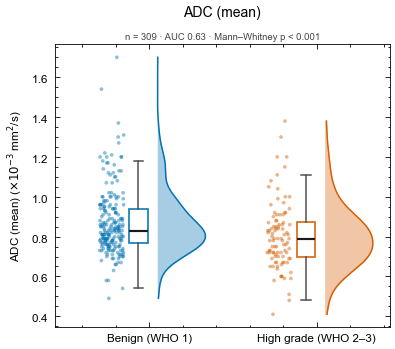

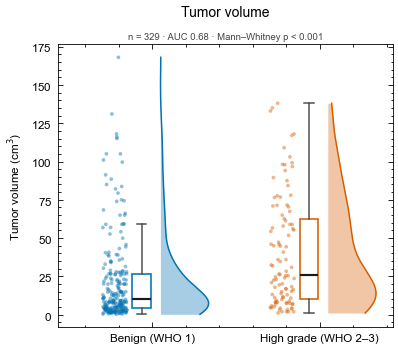

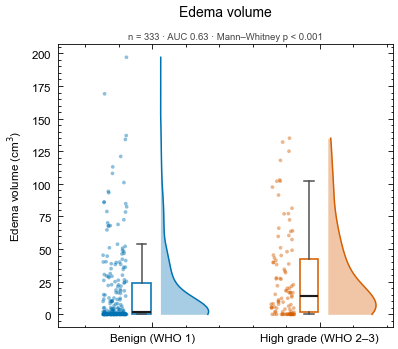

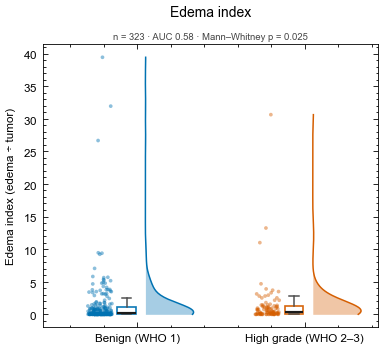

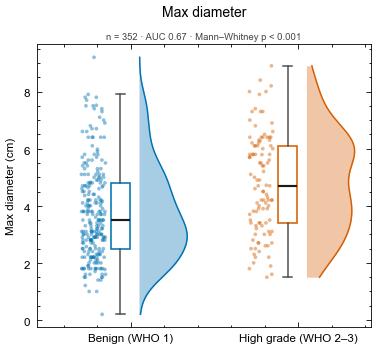

In [8]:
for metric in METRICS:
    art.figure(
        th.distribution_figure(df, metric, TARGET,
                               negative_label=NEGATIVE_LABEL,
                               positive_label=POSITIVE_LABEL),
        f"02_distribution_{metric.col}",
        caption=f"{metric.label} by WHO grade",
    )

---
# 04. Risk curves — where risk climbs fastest

Each metric is fitted as a restricted cubic spline (a smooth curve allowed to bend) against the risk of high grade. A likelihood-ratio test asks whether the bend is real; where it is, the **steepest point of the curve is the threshold**.

This is not a ROC question. Youden asks where the grades separate best; this asks where the *shape* of risk changes — and a metric can have one without the other.

In [9]:
RISK_TABLE, CURVES = rc.risk_curve_summary(
    df, METRICS, TARGET,
    risk_levels=RISK_LEVELS,
    n_boot=N_BOOTSTRAP_CURVE,
    seed=BOOTSTRAP_SEED,
)

# Kept separately so the per-metric figures can draw the bootstrap band
# without refitting several hundred splines each.
CURVE_BOOTSTRAPS = {
    m.col: rc.bootstrap_risk_curve(
        *th.metric_arrays(df, m, TARGET),
        direction=m.direction, log_fit=m.log_x,
        risk_levels=RISK_LEVELS, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    )
    for m in METRICS
}

art.table(RISK_TABLE, "03_risk_curves",
          caption="Non-linearity test, steepest-rise point, and risk crossings")

,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,ADC (mean),adc_value,$\times 10^{-3}$ mm$^2$/s,lower,309,96,0.63,raw x (clinical units),3,6.755,1,0.009,True,0.662,0.628,0.704,0.502,-1.752,False,7.1,0.607,0.015,True,False,True,0.311,1000,Risk climbs most steeply near ADC (mean) 0.662...,,0.791,0.745,1.300,0.999,0.663,0.597,0.713,0.926
1,Tumor volume,tumor_volume,cm$^3$,higher,329,101,0.68,raw x (clinical units),3,5.330,1,0.021,True,12.718,9.709,17.205,0.250,0.009,False,46.8,0.615,0.974,False,True,True,0.307,1000,Risk climbs most steeply near Tumor volume 12....,,18.519,12.088,30.590,1.000,62.262,32.035,102.015,0.801
2,Edema volume,edema_volume_cm3,cm$^3$,higher,333,99,0.63,raw x (clinical units),3,7.184,1,0.007,True,3.513,1.616,7.233,0.243,0.009,False,47.7,0.743,0.159,False,True,True,0.297,1000,Risk climbs most steeply near Edema volume 3.5...,,9.923,3.448,21.272,0.996,,21.473,109.228,0.281
3,Edema index,edema_index,edema ÷ tumor,higher,323,98,0.58,raw x (clinical units),3,3.935,1,0.047,True,0.091,0.066,0.257,0.270,0.107,False,40.9,0.574,0.002,True,False,True,0.303,1000,Risk climbs most steeply near Edema index 0.09...,,0.383,0.000,1.294,0.913,,0.723,6.551,0.058
4,Max diameter,max_diameter_cm,cm,higher,352,105,0.67,raw x (clinical units),3,0.449,1,0.503,False,3.558,2.958,6.365,0.260,0.083,False,46.0,0.104,0.773,False,False,False,0.298,1000,Risk rises steadily with Max diameter — no cur...,,4.042,3.353,4.989,1.000,6.819,5.657,7.656,0.788


💾 output/thresholds/tables/03_risk_curves.csv — 5 rows


,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,ADC (mean),adc_value,$\times 10^{-3}$ mm$^2$/s,lower,309,96,0.627054,raw x (clinical units),3,6.755446,1,0.009346,True,0.661894,0.628467,0.703673,0.502144,-1.752325,False,7.119741,0.607,0.015269,True,False,True,0.310680,1000,Risk climbs most steeply near ADC (mean) 0.662...,,0.791268,0.745048,1.300000,0.999,0.663118,0.596751,0.712755,0.926
1,Tumor volume,tumor_volume,cm$^3$,higher,329,101,0.678696,raw x (clinical units),3,5.329580,1,0.020966,True,12.717588,9.709452,17.205106,0.249540,0.008877,False,46.808511,0.615,0.973834,False,True,True,0.306991,1000,Risk climbs most steeply near Tumor volume 12....,,18.519291,12.088476,30.589615,1.000,62.261727,32.035105,102.015224,0.801
2,Edema volume,edema_volume_cm3,cm$^3$,higher,333,99,0.629068,raw x (clinical units),3,7.184318,1,0.007354,True,3.512563,1.615930,7.232814,0.243020,0.009227,False,47.747748,0.743,0.158691,False,True,True,0.297297,1000,Risk climbs most steeply near Edema volume 3.5...,,9.922525,3.448465,21.271705,0.996,NaN,21.473405,109.228413,0.281
3,Edema index,edema_index,edema ÷ tumor,higher,323,98,0.576803,raw x (clinical units),3,3.934991,1,0.047291,True,0.091454,0.065692,0.256634,0.269910,0.107293,False,40.866873,0.574,0.001948,True,False,True,0.303406,1000,Risk climbs most steeply near Edema index 0.09...,,0.383349,0.000000,1.293990,0.913,NaN,0.722628,6.551227,0.058
4,Max diameter,max_diameter_cm,cm,higher,352,105,0.674745,raw x (clinical units),3,0.449000,1,0.502810,False,3.557789,2.958200,6.364869,0.260440,0.082548,False,46.022727,0.104,0.773004,False,False,False,0.298295,1000,Risk rises steadily with Max diameter — no cur...,,4.041835,3.352865,4.988903,1.000,6.818702,5.657402,7.656438,0.788


### The reading view

`Non-linear?` is the gatekeeper: `no interior threshold` means the module refused to invent a number. `Patients below it` places the knee — one at the 47th percentile sits in the bulk of the cohort, one at the 7th rests on few patients.

In [10]:
RISK_READING = rc.risk_curve_reading_view(RISK_TABLE)
art.table(RISK_READING, "04_risk_curves_reading_view", formatted=False,
          caption="Plain-language answer: is there a threshold, and where?")

,Metric,n / events,Non-linear?,Steepest rise,Patients below it,Risk reaches 30%,Risk reaches 50%,Reading
0,ADC (mean),309 / 96,yes (p = 0.009),0.662 (0.628–0.704),7%,0.791 (0.745–1.3),0.663 (0.597–0.713),Risk climbs most steeply near ADC (mean) 0.662...
1,Tumor volume,329 / 101,yes (p = 0.021),12.7 (9.71–17.2),47%,18.5 (12.1–30.6),62.3 (32–102),Risk climbs most steeply near Tumor volume 12....
2,Edema volume,333 / 99,yes (p = 0.007),3.51 (1.62–7.23),48%,9.92 (3.45–21.3),never reached,Risk climbs most steeply near Edema volume 3.5...
3,Edema index,323 / 98,yes (p = 0.047),0.0915 (0.0657–0.257),41%,0.383 (0–1.29),never reached,Risk climbs most steeply near Edema index 0.09...
4,Max diameter,352 / 105,no (p = 0.503),no interior threshold,46%,4.04 (3.35–4.99),6.82 (5.66–7.66),Risk rises steadily with Max diameter — no cur...


💾 output/thresholds/tables/04_risk_curves_reading_view.csv — 5 rows


,Metric,n / events,Non-linear?,Steepest rise,Patients below it,Risk reaches 30%,Risk reaches 50%,Reading
0,ADC (mean),309 / 96,yes (p = 0.009),0.662 (0.628–0.704),7%,0.791 (0.745–1.3),0.663 (0.597–0.713),Risk climbs most steeply near ADC (mean) 0.662...
1,Tumor volume,329 / 101,yes (p = 0.021),12.7 (9.71–17.2),47%,18.5 (12.1–30.6),62.3 (32–102),Risk climbs most steeply near Tumor volume 12....
2,Edema volume,333 / 99,yes (p = 0.007),3.51 (1.62–7.23),48%,9.92 (3.45–21.3),never reached,Risk climbs most steeply near Edema volume 3.5...
3,Edema index,323 / 98,yes (p = 0.047),0.0915 (0.0657–0.257),41%,0.383 (0–1.29),never reached,Risk climbs most steeply near Edema index 0.09...
4,Max diameter,352 / 105,no (p = 0.503),no interior threshold,46%,4.04 (3.35–4.99),6.82 (5.66–7.66),Risk rises steadily with Max diameter — no cur...


### Multiple testing, pre-specified

Four non-linearity tests, one outcome: that family is pre-specified as the primary one, and Holm and Bonferroni are applied to it. Cut-point selection is not in the family — it is a choice, not a hypothesis test.

In [11]:
MULTIPLICITY = ev.multiplicity_table(RISK_TABLE)
art.table(MULTIPLICITY, "38_nonlinearity_multiplicity",
          caption="The four non-linearity LRTs: raw, Holm- and Bonferroni-adjusted")
art.table(ev.multiplicity_reading_view(MULTIPLICITY),
          "39_nonlinearity_multiplicity_reading_view", formatted=False,
          caption="Which measurements survive each correction")

n_holm = int(MULTIPLICITY["survives_holm"].sum())
n_bonf = int(MULTIPLICITY["survives_bonferroni"].sum())
n_tests = len(MULTIPLICITY)
dropped = list(MULTIPLICITY.loc[
    MULTIPLICITY["survives_holm"] & ~MULTIPLICITY["survives_bonferroni"], "metric"])

multiplicity_note = (
    f"Primary family: {n_tests} non-linearity likelihood-ratio tests. "
    f"{n_holm} of {n_tests} survive Holm adjustment; {n_bonf} of {n_tests} survive "
    f"Bonferroni"
    + (f" (Bonferroni additionally drops {', '.join(dropped)})." if dropped else ".")
)
print(multiplicity_note)
art.note(multiplicity_note)

,metric,column,family,n_tests,p_raw,p_holm,p_bonferroni,survives_raw,survives_holm,survives_bonferroni
0,ADC (mean),adc_value,non-linearity LRT (primary),5,0.009,0.037,0.047,True,True,True
1,Tumor volume,tumor_volume,non-linearity LRT (primary),5,0.021,0.063,0.105,True,False,False
2,Edema volume,edema_volume_cm3,non-linearity LRT (primary),5,0.007,0.037,0.037,True,True,True
3,Edema index,edema_index,non-linearity LRT (primary),5,0.047,0.095,0.236,True,False,False
4,Max diameter,max_diameter_cm,non-linearity LRT (primary),5,0.503,0.503,1.000,False,False,False


💾 output/thresholds/tables/38_nonlinearity_multiplicity.csv — 5 rows


,Metric,Non-linearity p,Holm-adjusted p,Holm,Bonferroni-adjusted p,Bonferroni
0,ADC (mean),= 0.009,= 0.037,survives,= 0.047,survives
1,Tumor volume,= 0.021,= 0.063,does not survive,= 0.105,does not survive
2,Edema volume,= 0.007,= 0.037,survives,= 0.037,survives
3,Edema index,= 0.047,= 0.095,does not survive,= 0.236,does not survive
4,Max diameter,= 0.503,= 0.503,does not survive,= 1.000,does not survive


💾 output/thresholds/tables/39_nonlinearity_multiplicity_reading_view.csv — 5 rows
Primary family: 5 non-linearity likelihood-ratio tests. 2 of 5 survive Holm adjustment; 2 of 5 survive Bonferroni.


### All four curves — the poster figure

No cut-points, just how risk moves with each measurement. Grey dots are the observed proportion in equal-count bins with Wilson intervals — if they do not track the curve, the spline is telling a story the patients do not support.

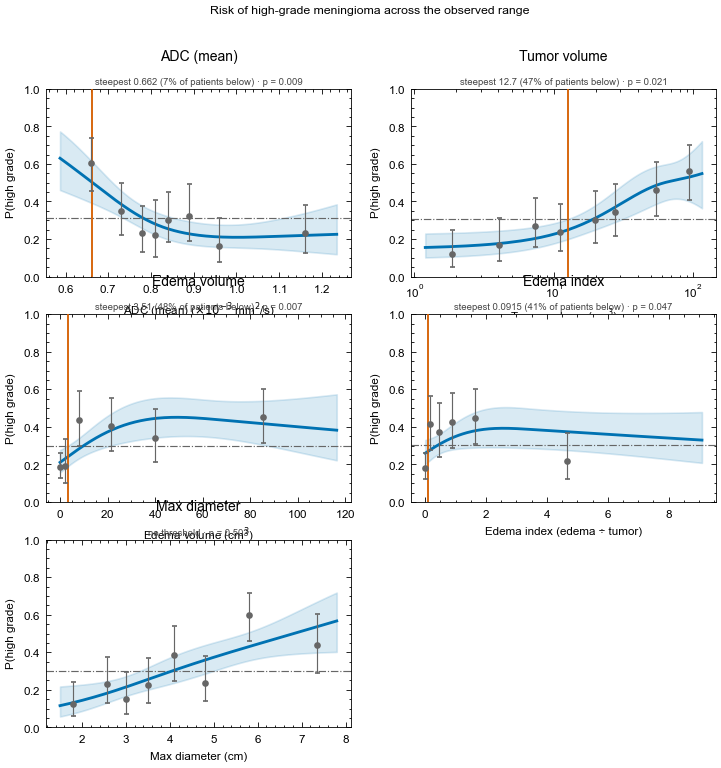

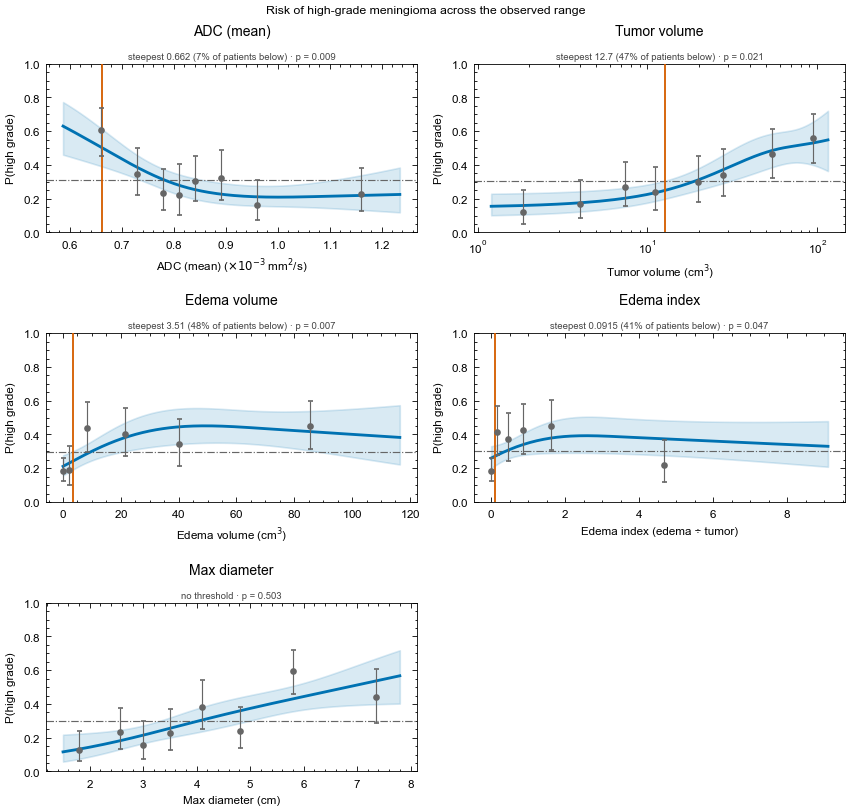

In [12]:
art.figure(rc.risk_curve_panel(df, METRICS, TARGET, CURVES), "05_risk_curves_panel",
           caption="Risk of high-grade meningioma across the observed range")

### Per metric, with the slope drawn

The right-hand panel plots the rise in risk per unit, so its peak *is* the steepest-rise point. A flat right panel, or a peak at the edge, means no such point exists.

/Users/andriszaguzovs/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


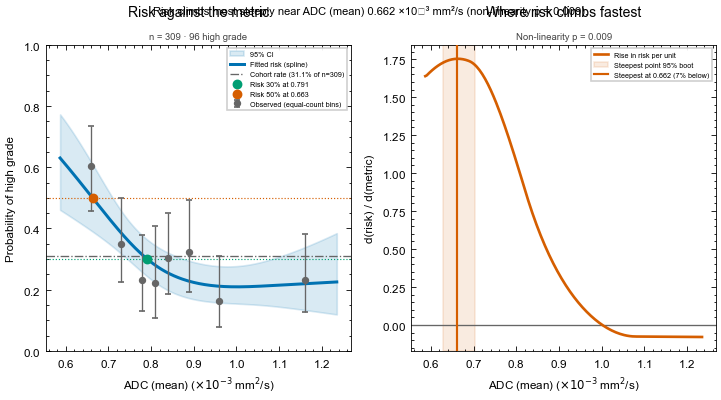

/Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/heavy_machinery/modelling_phase/plot_style.py:934: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.tight_layout()
/Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/heavy_machinery/modelling_phase/plot_style.py:938: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(out, **kwargs)


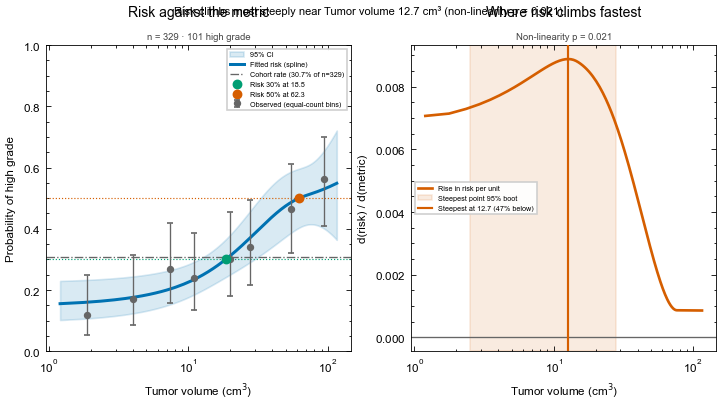

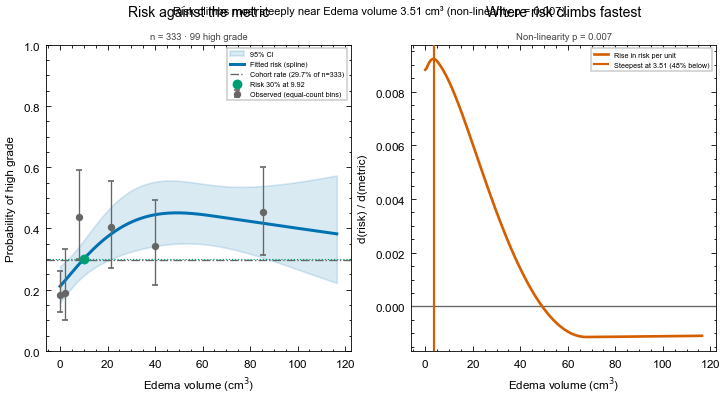

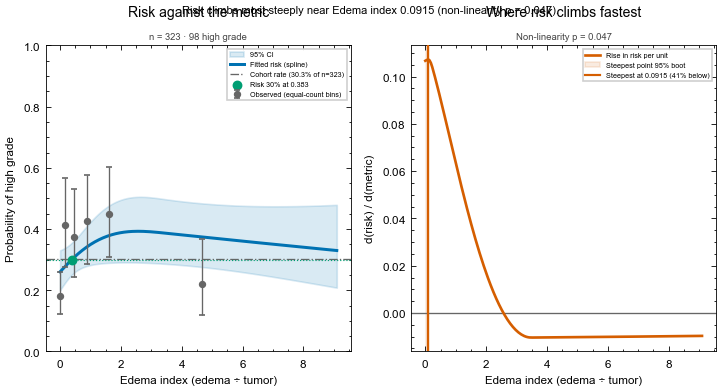

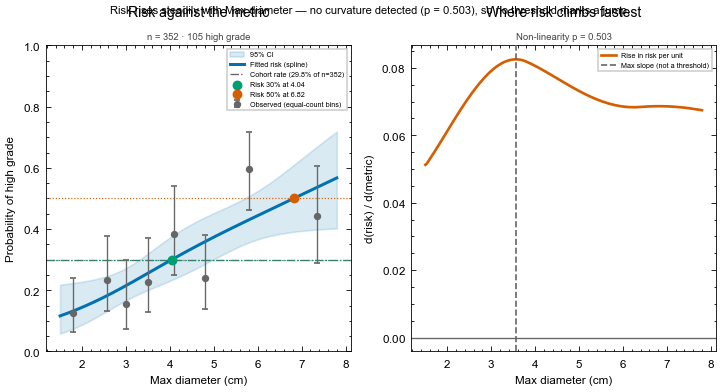

In [13]:
for metric in METRICS:
    art.figure(
        rc.risk_curve_figure(df, metric, TARGET, CURVES[metric.col],
                             boot=CURVE_BOOTSTRAPS[metric.col],
                             risk_levels=RISK_LEVELS),
        f"06_risk_curve_{metric.col}",
        caption=CURVES[metric.col].verdict(metric),
    )

### What §04 concluded

One line per metric, in the words that go under the figure.

In [14]:
for metric in METRICS:
    curve = CURVES[metric.col]
    mark = "🎯" if curve.knee_found else "➖"
    print(f"{mark} {curve.verdict(metric)}")
    art.note(curve.verdict(metric))

🎯 Risk climbs most steeply near ADC (mean) 0.662 ×10⁻³ mm²/s (non-linearity p = 0.009).
🎯 Risk climbs most steeply near Tumor volume 12.7 cm³ (non-linearity p = 0.021).
🎯 Risk climbs most steeply near Edema volume 3.51 cm³ (non-linearity p = 0.007).
🎯 Risk climbs most steeply near Edema index 0.0915 (non-linearity p = 0.047).
➖ Risk rises steadily with Max diameter — no curvature detected (p = 0.503), so no threshold marks a jump.


### Zero inflation — "no edema" is a category, not a small number

A third of the cohort has no peritumoral edema at all, so the lowest spline knot lands at zero and the "bend" is substantially edema **present versus absent**. Below: how many exact zeros, the risk either side of zero, presence scored as a yes/no test, and the curve refitted on non-zero values only.

,metric,column,n_analysed,n_zero,pct_zero,n_positive,smallest_positive,events_zero,risk_zero,risk_zero_lo,risk_zero_hi,events_positive,risk_positive,risk_positive_lo,risk_positive_hi,risk_ratio,zero_inflated,zero_inflation_floor_pct
0,ADC (mean),adc_value,309,0,0.0,309,0.41,0,,,,96,0.311,0.262,0.364,,False,10
1,Tumor volume,tumor_volume,329,0,0.0,329,0.30,0,,,,101,0.307,0.260,0.359,,False,10
2,Edema volume,edema_volume_cm3,333,122,36.6,211,0.20,23,0.189,0.129,0.267,76,0.360,0.298,0.427,1.911,True,10
3,Edema index,edema_index,323,113,35.0,210,0.01,22,0.195,0.132,0.277,76,0.362,0.300,0.429,1.859,True,10
4,Max diameter,max_diameter_cm,352,0,0.0,352,0.20,0,,,,105,0.298,0.253,0.348,,False,10


💾 output/thresholds/tables/34_zero_inflation.csv — 5 rows


,predictor,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,accuracy,accuracy_lo,accuracy_hi,AUC,OR,OR_lo,OR_hi,p,test,note,metric,column,rule,rule_label,youden_J
0,Edema volume present (> 0),333,76,135,23,99,0.768,0.675,0.840,0.423,0.362,0.487,0.360,0.298,0.427,0.811,0.733,0.871,0.526,0.472,0.579,0.60,2.42,1.421,4.132,<0.001,chi2,,Edema volume,edema_volume_cm3,presence,Edema volume present (> 0),0.191
1,Edema index present (> 0),323,76,134,22,91,0.776,0.683,0.847,0.404,0.342,0.470,0.362,0.300,0.429,0.805,0.723,0.868,0.517,0.463,0.571,0.59,2.35,1.362,4.042,0.002,chi2,,Edema index,edema_index,presence,Edema index present (> 0),0.180


💾 output/thresholds/tables/35_presence_rules.csv — 2 rows


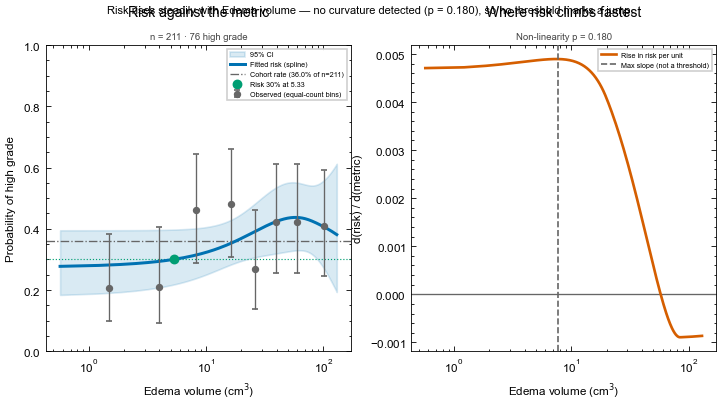

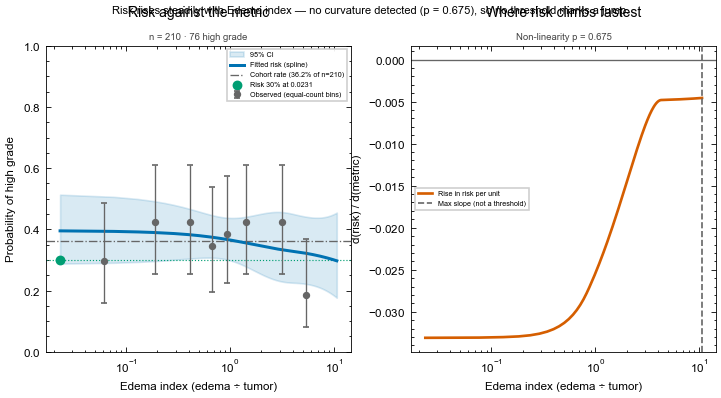

,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,Edema volume,edema_volume_cm3,cm$^3$,higher,211,76,0.58,raw x (clinical units),3,1.796,1,0.180,False,7.738,5.942,14.479,0.312,0.005,False,29.4,0.256,0.125,False,False,False,0.360,1000,Risk rises steadily with Edema volume — no cur...,,5.332,0.500,32.135,0.724,,25.592,117.574,0.275
1,Edema index,edema_index,edema ÷ tumor,higher,210,76,0.47,raw x (clinical units),3,0.176,1,0.675,False,10.644,0.156,0.408,0.297,-0.005,True,97.1,0.049,0.331,False,False,False,0.362,1000,Risk rises steadily with Edema index — no curv...,,0.023,0.013,0.464,0.705,,0.016,25.089,0.084


💾 output/thresholds/tables/36_risk_curves_nonzero_only.csv — 2 rows


,Fitted on,n,Non-linearity p,Steepest rise,95% CI,Metric
0,Whole cohort (zeros included),333 (99 high grade),= 0.007,3.51,1.62–7.23,Edema volume
1,Present vs absent (no measurement needed),333 (99 high grade),n/a — binary,"sens 77% / spec 42%, J 0.19",—,Edema volume
2,Only patients with a non-zero value,211 (76 high grade),= 0.180,no interior threshold,—,Edema volume
3,Whole cohort (zeros included),323 (98 high grade),= 0.047,0.0915,0.0657–0.257,Edema index
4,Present vs absent (no measurement needed),323 (98 high grade),n/a — binary,"sens 78% / spec 40%, J 0.18",—,Edema index
5,Only patients with a non-zero value,210 (76 high grade),= 0.675,no interior threshold,—,Edema index


💾 output/thresholds/tables/37_zero_inflation_comparison.csv — 6 rows
⚠️ Edema volume is zero in 122 of 333 measured patients (36.6%). Risk is 19% (13-27) with none and 36% (30-43) with any, a 1.9-fold difference before any cut-point is drawn.
⚠️ Edema index is zero in 113 of 323 measured patients (35.0%). Risk is 19% (13-28) with none and 36% (30-43) with any, a 1.9-fold difference before any cut-point is drawn.


In [15]:
ZERO_SHARE = rc.zero_share(df, METRICS, TARGET)
art.table(ZERO_SHARE, "34_zero_inflation",
          caption="Exact zeros per metric, with the risk on each side of zero")

PRESENCE_RULES = rc.presence_rules(df, METRICS, TARGET)
art.table(PRESENCE_RULES, "35_presence_rules",
          caption='"Is there any at all?" scored as a yes/no test, with the full 2x2')

# Refit the curve where the metric is a measurement rather than a category.
ZERO_INFLATED = [m for m in METRICS
                 if bool(ZERO_SHARE.set_index("column").loc[m.col, "zero_inflated"])]
POSITIVE_RISK_TABLE = pd.DataFrame()
if ZERO_INFLATED:
    parts = []
    for metric in ZERO_INFLATED:
        subset = rc.positive_only(df, metric)
        part, curves = rc.risk_curve_summary(
            subset, [metric], TARGET, risk_levels=RISK_LEVELS,
            n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
        )
        parts.append(part)
        # The §02 figure redrawn on patients who have some: what is left of
        # the bend once presence-versus-absence is taken out of it.
        boot = rc.bootstrap_risk_curve(
            *th.metric_arrays(subset, metric, TARGET),
            direction=metric.direction, log_fit=metric.log_x,
            risk_levels=RISK_LEVELS, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
        )
        art.figure(
            rc.risk_curve_figure(subset, metric, TARGET, curves[metric.col],
                                 boot=boot, risk_levels=RISK_LEVELS),
            f"36_risk_curve_nonzero_{metric.col}",
            caption=f"{metric.label}, patients with a non-zero value only — "
                    f"{curves[metric.col].verdict(metric)}",
        )
    POSITIVE_RISK_TABLE = pd.concat(parts, ignore_index=True)
    art.table(POSITIVE_RISK_TABLE, "36_risk_curves_nonzero_only",
              caption="Risk curves refitted on patients with a non-zero value")

    COMPARISONS = pd.concat(
        [rc.zero_inflation_comparison(RISK_TABLE, PRESENCE_RULES,
                                      POSITIVE_RISK_TABLE, m).assign(Metric=m.label)
         for m in ZERO_INFLATED],
        ignore_index=True,
    )
    art.table(COMPARISONS, "37_zero_inflation_comparison", formatted=False,
              caption="Whole cohort vs present/absent vs non-zero only, side by side")

for _, r in ZERO_SHARE[ZERO_SHARE["zero_inflated"]].iterrows():
    note = (
        f"{r['metric']} is zero in {r['n_zero']} of {r['n_analysed']} measured patients "
        f"({r['pct_zero']:.1f}%). Risk is {r['risk_zero'] * 100:.0f}% "
        f"({r['risk_zero_lo'] * 100:.0f}-{r['risk_zero_hi'] * 100:.0f}) with none and "
        f"{r['risk_positive'] * 100:.0f}% "
        f"({r['risk_positive_lo'] * 100:.0f}-{r['risk_positive_hi'] * 100:.0f}) with any, "
        f"a {r['risk_ratio']:.1f}-fold difference before any cut-point is drawn."
    )
    print(f"\u26a0\ufe0f {note}")
    art.note(note)

---
# 05. Single cut-points

A different question from §04: not where risk changes shape, but where to draw one line so the grades separate as well as possible.

Every cut-point the data can distinguish is scored — that table *is* the ROC curve. Five selection rules are applied (Youden, closest to the top-left corner, equal sensitivity and specificity, ≥90% specificity, ≥90% sensitivity), each with a bootstrap interval and an optimism-corrected `J`, because the winner was chosen on the same patients it is scored on.

In [16]:
THRESHOLD_TABLE = th.threshold_summary(
    df, METRICS, TARGET,
    literature_cutoffs=LITERATURE_CUTOFFS,   # 🟧 filled in at the top of the notebook
    n_boot=N_BOOTSTRAP,
    seed=BOOTSTRAP_SEED,
)
art.table(THRESHOLD_TABLE, "07_threshold_summary",
          caption="Every metric × rule, plus published cut-points, with Wilson CIs")

,metric,column,rule,operator,cutoff,cutoff_boot_lo,cutoff_boot_hi,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,OR,OR_lo,OR_hi,youden_J,youden_J_corrected,optimism,accuracy,p,test,n_bootstrap,rule_note,source,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean),adc_value,youden,≤,0.72,0.69,0.848,309.0,34.0,25.0,62.0,188.0,0.354,0.266,0.454,0.883,0.832,0.919,0.576,0.449,0.694,0.752,0.695,0.801,4.12,2.284,7.445,0.237,0.209,0.028,0.718,<0.001,chi2,1000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,adc_value ≤ 0.72,0.666,0.766,0.62
1,ADC (mean),adc_value,closest_01,≤,0.79,0.73,0.848,309.0,51.0,78.0,45.0,135.0,0.531,0.432,0.628,0.634,0.567,0.696,0.395,0.315,0.482,0.75,0.682,0.808,1.96,1.204,3.196,0.165,0.134,0.031,0.602,0.006,chi2,1000.0,nearest ROC point to the perfect corner,,,adc_value ≤ 0.79,0.546,0.655,0.58
2,ADC (mean),adc_value,equal_sens_spec,≤,0.81,0.79,0.83,309.0,54.0,93.0,42.0,120.0,0.562,0.463,0.657,0.563,0.496,0.628,0.367,0.294,0.448,0.741,0.668,0.802,1.66,1.021,2.696,0.126,0.129,-0.003,0.563,0.04,chi2,1000.0,where the sens and spec curves cross,,,adc_value ≤ 0.81,0.507,0.617,0.56
3,ADC (mean),adc_value,spec_ge_90,≤,0.7,0.69,0.72,309.0,26.0,17.0,70.0,196.0,0.271,0.192,0.367,0.92,0.876,0.95,0.605,0.456,0.736,0.737,0.681,0.786,4.28,2.192,8.364,0.191,0.187,0.004,0.718,<0.001,chi2,1000.0,best sens while spec ≥ 90% — rule-in,,,adc_value ≤ 0.7,0.666,0.766,0.6
4,ADC (mean),adc_value,sens_ge_90,≤,1.0,0.92,1.15,309.0,87.0,182.0,9.0,31.0,0.906,0.831,0.95,0.146,0.104,0.199,0.323,0.27,0.381,0.775,0.625,0.877,1.65,0.751,3.609,0.052,0.046,0.006,0.382,0.209,chi2,1000.0,best spec while sens ≥ 90% — rule-out,,,adc_value ≤ 1,0.329,0.437,0.53
5,Tumor volume,tumor_volume,youden,≥,15.1,6.78,44.8,329.0,68.0,91.0,33.0,137.0,0.673,0.577,0.757,0.601,0.536,0.662,0.428,0.353,0.505,0.806,0.74,0.858,3.1,1.895,5.08,0.274,0.228,0.046,0.623,<0.001,chi2,1000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,tumor_volume ≥ 15.1,0.57,0.674,0.64
6,Tumor volume,tumor_volume,closest_01,≥,16.4,10.9,31.0,329.0,66.0,87.0,35.0,141.0,0.653,0.557,0.739,0.618,0.554,0.679,0.431,0.356,0.511,0.801,0.736,0.853,3.06,1.874,4.985,0.272,0.244,0.028,0.629,<0.001,chi2,1000.0,nearest ROC point to the perfect corner,,,tumor_volume ≥ 16.4,0.576,0.68,0.64
7,Tumor volume,tumor_volume,equal_sens_spec,≥,17.1,14.098,22.6,329.0,63.0,87.0,38.0,141.0,0.624,0.526,0.712,0.618,0.554,0.679,0.42,0.344,0.5,0.788,0.722,0.841,2.69,1.657,4.356,0.242,0.242,0.0,0.62,<0.001,chi2,1000.0,where the sens and spec curves cross,,,tumor_volume ≥ 17.1,0.567,0.671,0.62
8,Tumor volume,tumor_volume,spec_ge_90,≥,61.4,44.4,77.6,329.0,27.0,22.0,74.0,206.0,0.267,0.191,0.361,0.904,0.858,0.935,0.551,0.413,0.681,0.736,0.681,0.784,3.42,1.833,6.367,0.171,0.162,0.009,0.708,<0.001,chi2,1000.0,best sens while spec ≥ 90% — rule-in,,,tumor_volume ≥ 61.4,0.657,0.755,0.59
9,Tumor volume,tumor_volume,sens_ge_90,≥,4.51,3.2,7.52,329.0,91.0,166.0,10.0,62.0,0.901,0.827,0.945,0.272,0.218,0.333,0.354,0.298,0.414,0.861,0.763,0.923,3.4,1.662,6.949,0.173,0.163,0.01,0.465,<0.001,chi2,1000.0,best spec while sens ≥ 90% — rule-out,,,tumor_volume ≥ 4.51,0.412,0.519,0.59


💾 output/thresholds/tables/07_threshold_summary.csv — 34 rows


,metric,column,rule,operator,cutoff,cutoff_boot_lo,cutoff_boot_hi,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,OR,OR_lo,OR_hi,youden_J,youden_J_corrected,optimism,accuracy,p,test,n_bootstrap,rule_note,source,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean),adc_value,youden,≤,0.720000,0.690000,0.848000,309.0,34.0,25.0,62.0,188.0,0.354167,0.265798,0.453757,0.882629,0.832478,0.919223,0.576271,0.449345,0.693873,0.752000,0.694924,0.801448,4.123871,2.284140,7.445388,0.236796,0.209147,0.027649,0.718447,9.536159e-07,chi2,1000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,adc_value ≤ 0.72,0.665854,0.765675,0.618398
1,ADC (mean),adc_value,closest_01,≤,0.790000,0.730000,0.848000,309.0,51.0,78.0,45.0,135.0,0.531250,0.432156,0.627939,0.633803,0.567266,0.695599,0.395349,0.315177,0.481573,0.750000,0.681965,0.807587,1.961538,1.203778,3.196298,0.165053,0.133827,0.031225,0.601942,6.475488e-03,chi2,1000.0,nearest ROC point to the perfect corner,,,adc_value ≤ 0.79,0.546433,0.654947,0.582526
2,ADC (mean),adc_value,equal_sens_spec,≤,0.810000,0.790000,0.830000,309.0,54.0,93.0,42.0,120.0,0.562500,0.462759,0.657432,0.563380,0.496235,0.628280,0.367347,0.293719,0.447732,0.740741,0.668235,0.802093,1.658986,1.020693,2.696437,0.125880,0.129050,-0.003170,0.563107,4.032192e-02,chi2,1000.0,where the sens and spec curves cross,,,adc_value ≤ 0.81,0.507364,0.617300,0.562940
3,ADC (mean),adc_value,spec_ge_90,≤,0.700000,0.690000,0.720000,309.0,26.0,17.0,70.0,196.0,0.270833,0.192038,0.367263,0.920188,0.875914,0.949574,0.604651,0.455791,0.736347,0.736842,0.680822,0.786118,4.282353,2.192445,8.364426,0.191021,0.187078,0.003943,0.718447,7.134539e-06,chi2,1000.0,best sens while spec ≥ 90% — rule-in,,,adc_value ≤ 0.7,0.665854,0.765675,0.595511
4,ADC (mean),adc_value,sens_ge_90,≤,1.000000,0.920000,1.150000,309.0,87.0,182.0,9.0,31.0,0.906250,0.831347,0.949892,0.145540,0.104464,0.199174,0.323420,0.270345,0.381467,0.775000,0.624969,0.876839,1.646520,0.751103,3.609396,0.051790,0.045678,0.006112,0.381877,2.094788e-01,chi2,1000.0,best spec while sens ≥ 90% — rule-out,,,adc_value ≤ 1,0.329470,0.437185,0.525895
5,Tumor volume,tumor_volume,youden,≥,15.100000,6.780000,44.800000,329.0,68.0,91.0,33.0,137.0,0.673267,0.576916,0.756921,0.600877,0.536146,0.662265,0.427673,0.353372,0.505386,0.805882,0.739941,0.858305,3.102231,1.894598,5.079621,0.274145,0.227836,0.046309,0.623100,4.439216e-06,chi2,1000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,tumor_volume ≥ 15.1,0.569598,0.673761,0.637072
6,Tumor volume,tumor_volume,closest_01,≥,16.400000,10.900000,31.000000,329.0,66.0,87.0,35.0,141.0,0.653465,0.556580,0.739105,0.618421,0.553898,0.679019,0.431373,0.355525,0.510582,0.801136,0.736015,0.853393,3.056158,1.873683,4.984887,0.271886,0.243621,0.028266,0.629179,5.103443e-06,chi2,1000.0,nearest ROC point to the perfect corner,,,tumor_volume ≥ 16.4,0.575775,0.679602,0.635943
7,Tumor volume,tumor_volume,equal_sens_spec,≥,17.100000,14.097500,22.600000,329.0,63.0,87.0,38.0,141.0,0.623762,0.526386,0.712069,0.618421,0.553898,0.679019,0.420000,0.343980,0.500015,0.787709,0.722084,0.841246,2.686933,1.657331,4.356165,0.242183,0.241812,0.000371,0.620061,4.738524e-05,chi2,1000.0,where the sens and spec curves cross,,,tumor_volume ≥ 17.1,0.566513,0.670837,0.621092
8,Tumor volume,tumor_volume,spec_ge_90,≥,61.400000,44.400000,77.600000,329.0,27.0,22.0,74.0,206.0,0.267327,0.190710,0.360994,0.903509,0.858232,0.935413,0.551020,0.413151,0.681472,0.735714,0.681127,0.783921,3.416462,1.833343,6.366626,0.170836,0.161980,0.008855,0.708207,5.958204e-05,chi2,1000.0,best sens while spec ≥ 90% — rule-in,,,tumor_volume ≥ 61.4,0.656908,0.754700,0.585418
9,Tumor volume,tumor_volume,sens_ge_90,≥,4.510000,3.200000,7.520000,329.0,91.0,166.0,10.0,62.0,0.900990,0.827268,0.945327,0.271930,0.218309,0.333109,0.354086,0.298158,0.414311,0.861111,0.762868,0.922773,3.398795,1.662369,6.949005,0.172920,0.163064,0.009856

### Reading view

The columns a clinician reads. The gap between `J` and `J (corr.)` is what you lose by having chosen the cut-point on this cohort.

In [17]:
THRESHOLD_READING = th.reading_view(THRESHOLD_TABLE)
art.table(THRESHOLD_READING, "08_threshold_reading_view", formatted=False,
          caption="Cut-points with sensitivity, specificity, PPV, NPV and optimism-corrected J")

,Metric,Rule,Cut-point,Cut-point 95% CI,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),OR (95% CI),J,J (corr.),Reading
0,ADC (mean),youden,≤0.72,0.69–0.848,309.0,35% (27–45),88% (83–92),58% (45–69),75% (69–80),4.12 (2.28–7.45),0.24,0.21,
1,ADC (mean),closest_01,≤0.79,0.73–0.848,309.0,53% (43–63),63% (57–70),40% (32–48),75% (68–81),1.96 (1.20–3.20),0.17,0.13,
2,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,309.0,56% (46–66),56% (50–63),37% (29–45),74% (67–80),1.66 (1.02–2.70),0.13,0.13,
3,ADC (mean),spec_ge_90,≤0.7,0.69–0.72,309.0,27% (19–37),92% (88–95),60% (46–74),74% (68–79),4.28 (2.19–8.36),0.19,0.19,
4,ADC (mean),sens_ge_90,≤1,0.92–1.15,309.0,91% (83–95),15% (10–20),32% (27–38),78% (62–88),1.65 (0.75–3.61),0.05,0.05,
5,Tumor volume,youden,≥15.1,6.78–44.8,329.0,67% (58–76),60% (54–66),43% (35–51),81% (74–86),3.10 (1.89–5.08),0.27,0.23,
6,Tumor volume,closest_01,≥16.4,10.9–31,329.0,65% (56–74),62% (55–68),43% (36–51),80% (74–85),3.06 (1.87–4.98),0.27,0.24,
7,Tumor volume,equal_sens_spec,≥17.1,14.1–22.6,329.0,62% (53–71),62% (55–68),42% (34–50),79% (72–84),2.69 (1.66–4.36),0.24,0.24,
8,Tumor volume,spec_ge_90,≥61.4,44.4–77.6,329.0,27% (19–36),90% (86–94),55% (41–68),74% (68–78),3.42 (1.83–6.37),0.17,0.16,
9,Tumor volume,sens_ge_90,≥4.51,3.2–7.52,329.0,90% (83–95),27% (22–33),35% (30–41),86% (76–92),3.40 (1.66–6.95),0.17,0.16,


💾 output/thresholds/tables/08_threshold_reading_view.csv — 34 rows


,Metric,Rule,Cut-point,Cut-point 95% CI,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),OR (95% CI),J,J (corr.),Reading
0,ADC (mean),youden,≤0.72,0.69–0.848,309.0,35% (27–45),88% (83–92),58% (45–69),75% (69–80),4.12 (2.28–7.45),0.24,0.21,
1,ADC (mean),closest_01,≤0.79,0.73–0.848,309.0,53% (43–63),63% (57–70),40% (32–48),75% (68–81),1.96 (1.20–3.20),0.17,0.13,
2,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,309.0,56% (46–66),56% (50–63),37% (29–45),74% (67–80),1.66 (1.02–2.70),0.13,0.13,
3,ADC (mean),spec_ge_90,≤0.7,0.69–0.72,309.0,27% (19–37),92% (88–95),60% (46–74),74% (68–79),4.28 (2.19–8.36),0.19,0.19,
4,ADC (mean),sens_ge_90,≤1,0.92–1.15,309.0,91% (83–95),15% (10–20),32% (27–38),78% (62–88),1.65 (0.75–3.61),0.05,0.05,
5,Tumor volume,youden,≥15.1,6.78–44.8,329.0,67% (58–76),60% (54–66),43% (35–51),81% (74–86),3.10 (1.89–5.08),0.27,0.23,
6,Tumor volume,closest_01,≥16.4,10.9–31,329.0,65% (56–74),62% (55–68),43% (36–51),80% (74–85),3.06 (1.87–4.98),0.27,0.24,
7,Tumor volume,equal_sens_spec,≥17.1,14.1–22.6,329.0,62% (53–71),62% (55–68),42% (34–50),79% (72–84),2.69 (1.66–4.36),0.24,0.24,
8,Tumor volume,spec_ge_90,≥61.4,44.4–77.6,329.0,27% (19–36),90% (86–94),55% (41–68),74% (68–78),3.42 (1.83–6.37),0.17,0.16,
9,Tumor volume,sens_ge_90,≥4.51,3.2–7.52,329.0,90% (83–95),27% (22–33),35% (30–41),86% (76–92),3.40 (1.66–6.95),0.17,0.16,


### Youden vs the whole trade-off

Both panels come from the same ROC table. **Left:** the curve with Youden's *J* drawn as the vertical gap off the diagonal. **Right:** sensitivity and specificity against the cut-point itself, which is where you read what a different line would cost.

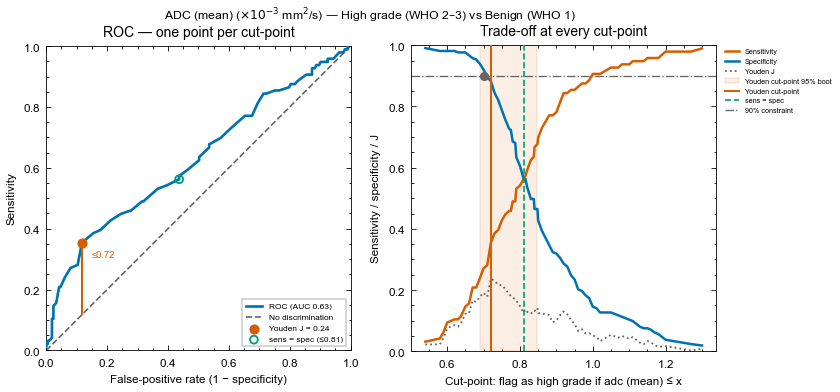

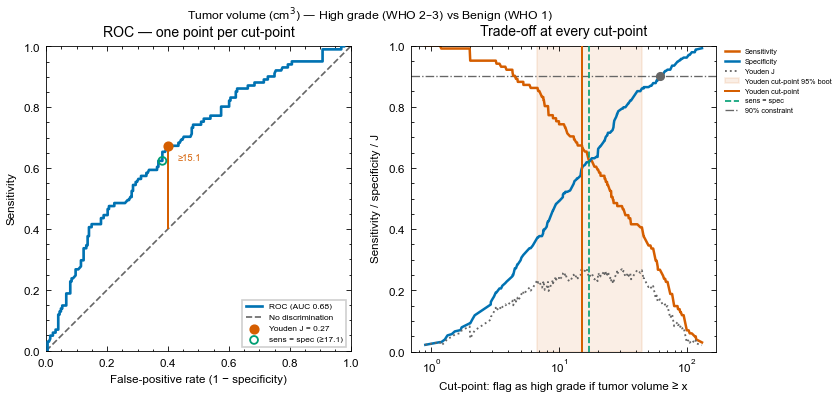

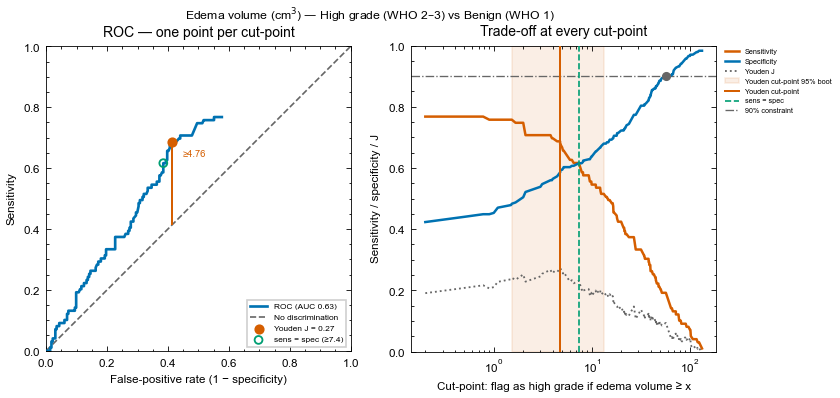

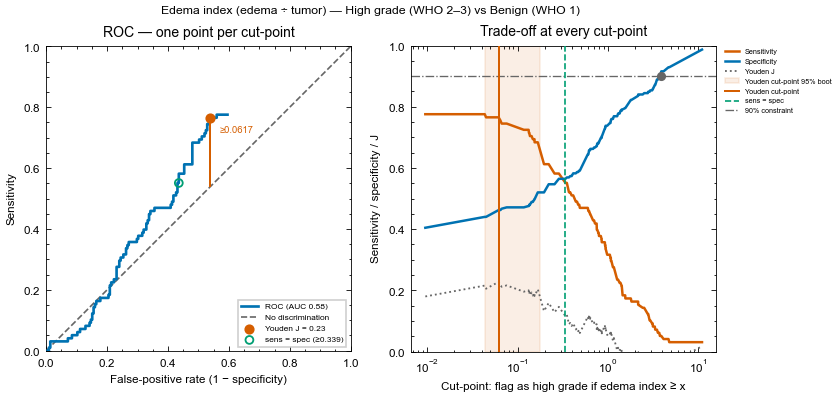

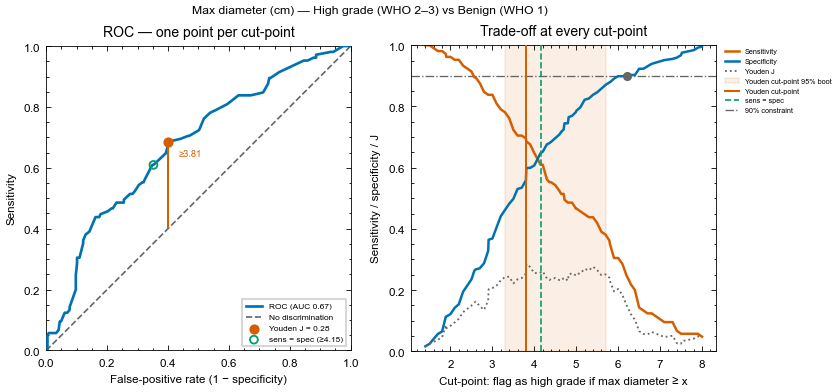

In [18]:
for metric in METRICS:
    art.figure(
        th.threshold_figure(df, metric, TARGET, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED,
                            positive_label=POSITIVE_LABEL, negative_label=NEGATIVE_LABEL),
        f"09_thresholds_{metric.col}",
        caption=f"{metric.label}: ROC and the full cut-point trade-off",
    )

### All metrics on one ROC

Discrimination without any cut-point choice. A curve hugging the diagonal belongs to a metric with no cut-point worth arguing about.

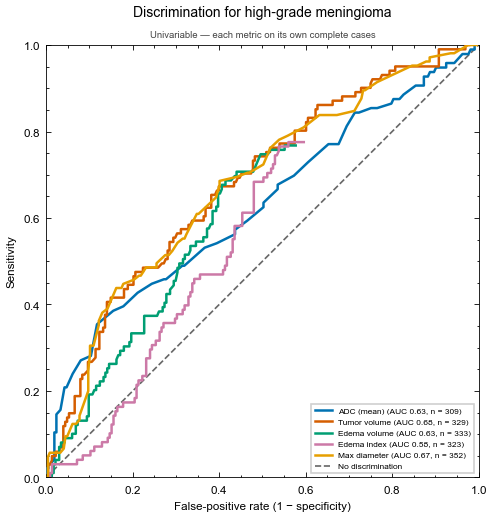

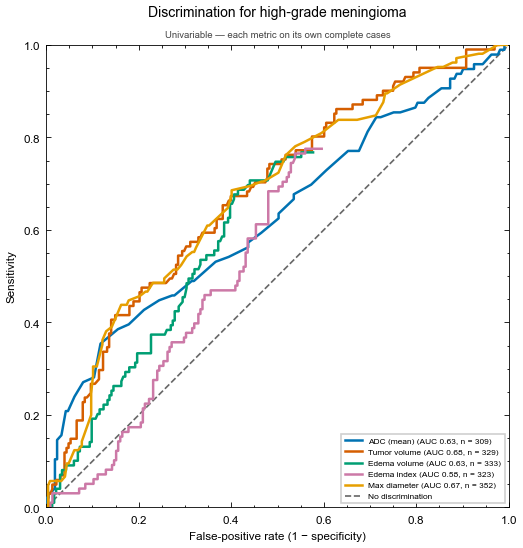

In [19]:
art.figure(th.combined_roc_figure(df, METRICS, TARGET), "10_combined_roc",
           caption="Univariable discrimination, each metric on its own complete cases")

---
# 06. Combinations — do two cut-points beat one?

**The cut-points are frozen before they are combined**: they come from §05 or from the literature, and only the way of joining them varies. Searching cut-points and rules together would be thousands of comparisons on ~105 events.

Singles, then every AND and OR pair, then count rules ("≥ 2 of 4 criteria").

In [20]:
# 🟧 Which rule freezes the cut-points. "youden" is the field convention;
#    swap for "spec_ge_90" to build a rule-in combination instead.
COMBINATION_RULE = "youden"

CUTPOINTS = cb.cutpoints_for_rule(df, METRICS, TARGET, COMBINATION_RULE)

# Published cut-points combined with each other need no optimism correction at
# all — nothing about them was chosen on these patients.
LITERATURE_CUTPOINTS = cb.cutpoints_from_literature(METRICS, LITERATURE_CUTOFFS)

print(f"Frozen at the {COMBINATION_RULE} cut-point:")
for cp in CUTPOINTS:
    print(f"  • {cp.label}")
print("\nPublished, for comparison:")
for cp in LITERATURE_CUTPOINTS:
    print(f"  • {cp.label}   [{cp.source}]")

art.table(st.flag_missingness(df, CUTPOINTS), "11_flag_missingness",
          caption="How many patients have every flag observed")

Frozen at the youden cut-point:
  • ADC (mean) ≤ 0.72
  • Tumor volume ≥ 15.1
  • Edema volume ≥ 4.76
  • Edema index ≥ 0.0617
  • Max diameter ≥ 3.81

Published, for comparison:
  • Edema index ≥ 1   [Frati, Armocida et al., Tomography 2022;8(4):1987–1996 (recurrence)]
  • Edema index ≥ 2.01   [Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 (KPS decline, ≥60 y; range low)]
  • Edema index ≥ 3.37   [Loewenstern et al., Oper Neurosurg 2019;16(3):281–291 (KPS decline, ≥60 y; range high)]
  • Edema volume ≥ 3.64   [Adeli, Spille et al., Oncotarget 2018;9(89):35974–35982 (brain invasion)]
  • Tumor volume ≥ 13.9   [Shin, Kim, Cheong et al., PLoS One 2021;16(6):e0252945 (edema presence)]
  • Tumor volume ≥ 26.4   [Recurrence in atypical meningioma, PMID 37867351 (3-year recurrence)]
  • Max diameter ≥ 3   [Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 (WHO grade II, OR 1.69)]
  • Max diameter ≥ 6   [Magill, Young, Chae et al., Neurosurg Focus 2018;44(4):E4 (WHO grade II, 

,n_patients,n_all_flags_observed,n_some_flag_missing,pct_scorable,k_criteria
0,352,304,48,86.4,5


💾 output/thresholds/tables/11_flag_missingness.csv — 1 rows


,n_patients,n_all_flags_observed,n_some_flag_missing,pct_scorable,k_criteria
0,352,304,48,86.363636,5


### The full menu

Scored with the pipeline's own `binary_diagnostic_metrics`, so these rows are directly comparable with the modelling notebook. Triples are available but off — an AND of three flags leaves single-digit cells.

In [21]:
RULE_MENU = cb.full_rule_menu(df, CUTPOINTS, TARGET)
art.table(RULE_MENU, "12_combination_menu",
          caption="Single, AND, OR and count rules with full 2×2 metrics")

COMBINATION_READING = cb.combination_reading_view(RULE_MENU)
art.table(COMBINATION_READING, "13_combination_reading_view", formatted=False,
          caption="Every rule ranked by Youden J")

,rule_label,kind,n_criteria,members,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,accuracy,p,test,note,predictor,accuracy_lo,accuracy_hi,AUC,OR,OR_lo,OR_hi
0,ADC (mean) ≤ 0.72,single,1,ADC (mean) ≤0.72,309,34,25,62,188,0.354,0.266,0.454,0.883,0.832,0.919,0.576,0.449,0.694,0.752,0.695,0.801,0.237,0.718,<0.001,chi2,,ADC (mean) ≤ 0.72,0.666,0.766,0.62,4.12,2.284,7.445
1,Tumor volume ≥ 15.1,single,1,Tumor volume ≥15.1,329,68,91,33,137,0.673,0.577,0.757,0.601,0.536,0.662,0.428,0.353,0.505,0.806,0.740,0.858,0.274,0.623,<0.001,chi2,,Tumor volume ≥ 15.1,0.570,0.674,0.64,3.10,1.895,5.080
2,Edema volume ≥ 4.76,single,1,Edema volume ≥4.76,333,68,97,31,137,0.687,0.590,0.770,0.585,0.521,0.647,0.412,0.340,0.488,0.815,0.750,0.867,0.272,0.616,<0.001,chi2,,Edema volume ≥ 4.76,0.562,0.666,0.64,3.10,1.883,5.098
3,Edema index ≥ 0.0617,single,1,Edema index ≥0.0617,323,75,121,23,104,0.765,0.672,0.838,0.462,0.398,0.527,0.383,0.317,0.452,0.819,0.743,0.876,0.228,0.554,<0.001,chi2,,Edema index ≥ 0.0617,0.500,0.607,0.61,2.80,1.640,4.789
4,Max diameter ≥ 3.81,single,1,Max diameter ≥3.81,352,72,99,33,148,0.686,0.592,0.767,0.599,0.537,0.658,0.421,0.350,0.496,0.818,0.755,0.867,0.285,0.625,<0.001,chi2,,Max diameter ≥ 3.81,0.573,0.674,0.64,3.26,2.010,5.294
5,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,and,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,320,24,17,73,206,0.247,0.172,0.342,0.924,0.881,0.952,0.585,0.434,0.722,0.738,0.684,0.786,0.171,0.719,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,0.667,0.765,0.59,3.98,2.026,7.834
6,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,318,78,99,22,119,0.780,0.689,0.850,0.546,0.480,0.611,0.441,0.370,0.514,0.844,0.775,0.895,0.326,0.619,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.565,0.671,0.66,4.26,2.476,7.336
7,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,and,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,331,24,13,75,219,0.242,0.169,0.335,0.944,0.907,0.967,0.649,0.488,0.782,0.745,0.692,0.791,0.186,0.734,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,0.684,0.779,0.59,5.39,2.613,11.121
8,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,311,78,109,18,106,0.812,0.723,0.878,0.493,0.427,0.559,0.417,0.349,0.489,0.855,0.782,0.906,0.306,0.592,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,0.536,0.645,0.65,4.21,2.364,7.512
9,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,and,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,319,27,13,71,208,0.276,0.197,0.371,0.941,0.902,0.965,0.675,0.520,0.799,0.746,0.691,0.793,0.217,0.737,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,0.686,0.782,0.61,6.08,2.978,12.430


💾 output/thresholds/tables/12_combination_menu.csv — 30 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,OR (95% CI),J
27,≥ 3 of 5 criteria,count,304,69% (59–77),66% (60–72),47% (39–56),83% (76–88),64/71/29/140,4.35 (2.58–7.35),0.35
12,ADC (mean) ≤ 0.72 OR Max diameter ≥ 3.81,or,328,80% (72–87),53% (46–59),43% (37–51),86% (79–90),82/107/20/119,4.56 (2.62–7.94),0.33
6,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,318,78% (69–85),55% (48–61),44% (37–51),84% (78–89),78/99/22/119,4.26 (2.48–7.34),0.33
23,Edema index ≥ 0.0617 AND Max diameter ≥ 3.81,and,336,58% (48–67),73% (67–79),48% (39–57),80% (75–85),58/63/42/173,3.79 (2.32–6.19),0.31
8,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,311,81% (72–88),49% (43–56),42% (35–49),85% (78–91),78/109/18/106,4.21 (2.36–7.51),0.31
17,Tumor volume ≥ 15.1 AND Max diameter ≥ 3.81,and,342,62% (52–71),67% (61–73),45% (37–53),80% (74–85),64/79/39/160,3.32 (2.05–5.38),0.29
26,≥ 2 of 5 criteria,count,304,85% (76–91),44% (38–51),40% (34–47),87% (79–92),79/118/14/93,4.45 (2.37–8.35),0.29
14,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,327,85% (77–91),44% (37–50),40% (34–47),87% (79–92),86/127/15/99,4.47 (2.43–8.21),0.29
4,Max diameter ≥ 3.81,single,352,69% (59–77),60% (54–66),42% (35–50),82% (76–87),72/99/33/148,3.26 (2.01–5.29),0.28
21,Edema volume ≥ 4.76 AND Max diameter ≥ 3.81,and,339,54% (44–63),74% (69–80),47% (38–56),79% (74–84),54/61/46/178,3.43 (2.10–5.59),0.28


💾 output/thresholds/tables/13_combination_reading_view.csv — 30 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,OR (95% CI),J
27,≥ 3 of 5 criteria,count,304,69% (59–77),66% (60–72),47% (39–56),83% (76–88),64/71/29/140,4.35 (2.58–7.35),0.35
12,ADC (mean) ≤ 0.72 OR Max diameter ≥ 3.81,or,328,80% (72–87),53% (46–59),43% (37–51),86% (79–90),82/107/20/119,4.56 (2.62–7.94),0.33
6,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,318,78% (69–85),55% (48–61),44% (37–51),84% (78–89),78/99/22/119,4.26 (2.48–7.34),0.33
23,Edema index ≥ 0.0617 AND Max diameter ≥ 3.81,and,336,58% (48–67),73% (67–79),48% (39–57),80% (75–85),58/63/42/173,3.79 (2.32–6.19),0.31
8,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,311,81% (72–88),49% (43–56),42% (35–49),85% (78–91),78/109/18/106,4.21 (2.36–7.51),0.31
17,Tumor volume ≥ 15.1 AND Max diameter ≥ 3.81,and,342,62% (52–71),67% (61–73),45% (37–53),80% (74–85),64/79/39/160,3.32 (2.05–5.38),0.29
26,≥ 2 of 5 criteria,count,304,85% (76–91),44% (38–51),40% (34–47),87% (79–92),79/118/14/93,4.45 (2.37–8.35),0.29
14,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,327,85% (77–91),44% (37–50),40% (34–47),87% (79–92),86/127/15/99,4.47 (2.43–8.21),0.29
4,Max diameter ≥ 3.81,single,352,69% (59–77),60% (54–66),42% (35–50),82% (76–87),72/99/33/148,3.26 (2.01–5.29),0.28
21,Edema volume ≥ 4.76 AND Max diameter ≥ 3.81,and,339,54% (44–63),74% (69–80),47% (38–56),79% (74–84),54/61/46/178,3.43 (2.10–5.59),0.28


### Every rule in one space

Each rule as a point in sensitivity–specificity space, singles as diamonds; dotted diagonals join rules that are equally good under Youden. A combination helps only if it sits **off** that band, up and to the right of every single.

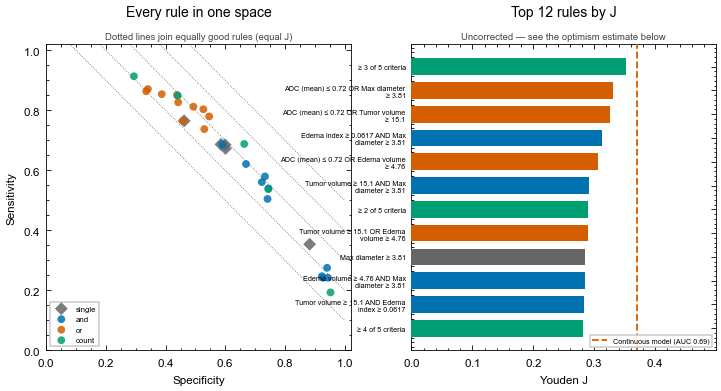

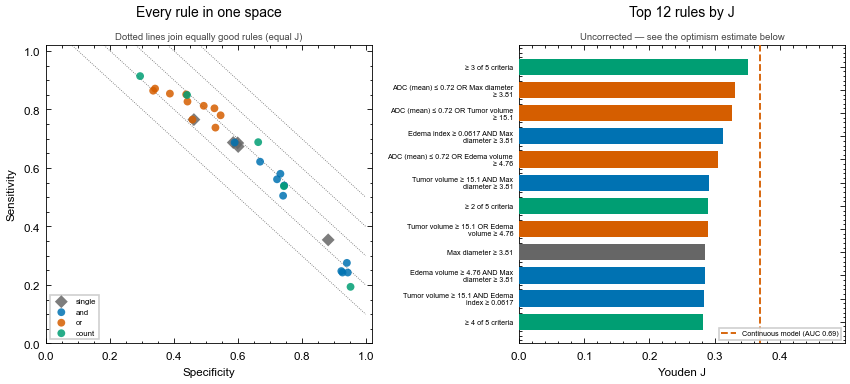

In [22]:
CONTINUOUS_BENCHMARK = cb.continuous_model_benchmark(
    df, METRICS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
art.figure(cb.combination_figure(RULE_MENU, benchmark=CONTINUOUS_BENCHMARK),
           "14_combination_space",
           caption="All rules in sensitivity–specificity space, with the continuous-model benchmark")

### The count score

The most usable output here: count how many criteria the tumor ticks and read the risk off the bar. Wilson intervals and `k/n` are drawn because the end bars rest on few patients.

,n_criteria_met,n,n_high_grade,risk,risk_lo,risk_hi
0,0,70,8,0.114,0.059,0.210
1,1,37,6,0.162,0.077,0.311
2,2,62,15,0.242,0.152,0.362
3,3,31,14,0.452,0.292,0.622
4,4,76,32,0.421,0.316,0.533
5,5,28,18,0.643,0.458,0.793


💾 output/thresholds/tables/15_count_score.csv — 6 rows


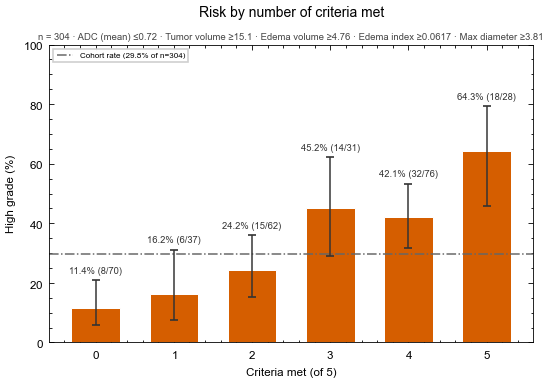

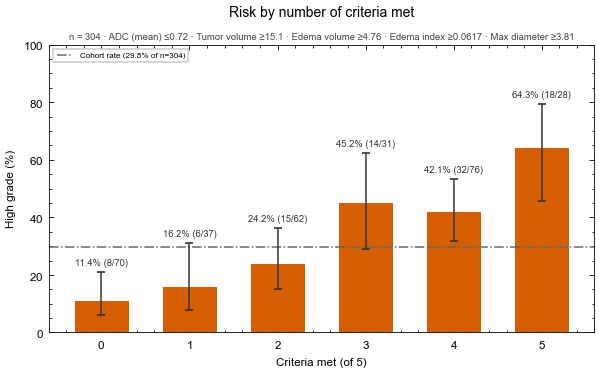

In [23]:
COUNT_TABLE = cb.count_score_table(df, CUTPOINTS, TARGET)
art.table(COUNT_TABLE, "15_count_score",
          caption="Observed high-grade rate by number of criteria met")

art.figure(
    cb.count_score_figure(COUNT_TABLE, cutpoints=CUTPOINTS,
                          prevalence=float(df[TARGET].astype("boolean").mean())),
    "16_count_score",
    caption="Risk by number of criteria met",
)

### The verdict on combining

Read `best_rule_J_corrected` against `best_single_J_corrected` (both corrected), then `winner_stability` — how often that rule actually wins — and `continuous_J_equivalent`, the uncut model.

In [24]:
BEST_RULE = cb.bootstrap_best_rule(
    df, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
# The same optimism procedure, restricted to the four singles. Without it the
# comparison is a corrected combination against an uncorrected single, and the
# whole of the single's own selection optimism is credited to the combination.
BEST_SINGLE = cb.bootstrap_best_rule(
    df, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    kinds=("single",),
)
auc_corrected = CONTINUOUS_BENCHMARK["AUC_corrected"]

COMBINATION_VERDICT = pd.DataFrame([{
    "best_single_rule": BEST_SINGLE["best_rule"],
    "best_single_J": BEST_SINGLE["J_apparent"],
    "best_single_J_corrected": BEST_SINGLE["J_corrected"],
    "best_single_selection_optimism": BEST_SINGLE["optimism"],
    "best_single_stability": BEST_SINGLE["winner_stability"],
    "best_rule": BEST_RULE["best_rule"],
    "best_rule_J": BEST_RULE["J_apparent"],
    "best_rule_J_corrected": BEST_RULE["J_corrected"],
    "selection_optimism": BEST_RULE["optimism"],
    "winner_stability": BEST_RULE["winner_stability"],
    "gain_apparent": BEST_RULE["J_apparent"] - BEST_SINGLE["J_apparent"],
    # Corrected against corrected — the only like-for-like comparison.
    "gain_vs_best_single": BEST_RULE["J_corrected"] - BEST_SINGLE["J_corrected"],
    "continuous_AUC_corrected": auc_corrected,
    "continuous_J_equivalent": 2.0 * (auc_corrected - 0.5),
    "n_used_continuous": CONTINUOUS_BENCHMARK["n_used"],
}])
art.table(COMBINATION_VERDICT, "17_combination_verdict",
          caption="Does combining cut-points beat the best single one?")

,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,Max diameter ≥ 3.81,0.285,0.239,0.046,0.327,≥ 3 of 5 criteria,0.352,0.31,0.042,0.404,0.067,0.071,0.69,0.37,304


💾 output/thresholds/tables/17_combination_verdict.csv — 1 rows


,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,Max diameter ≥ 3.81,0.284905,0.238551,0.046353,0.327,≥ 3 of 5 criteria,0.351679,0.309709,0.04197,0.404,0.066775,0.071158,0.685033,0.370067,304


In [25]:
gain = float(COMBINATION_VERDICT["gain_vs_best_single"].iloc[0])
single_corr = float(COMBINATION_VERDICT["best_single_J_corrected"].iloc[0])
stability = float(COMBINATION_VERDICT["winner_stability"].iloc[0])
cont_equiv = float(COMBINATION_VERDICT["continuous_J_equivalent"].iloc[0])
best_corr = float(COMBINATION_VERDICT["best_rule_J_corrected"].iloc[0])

verdict = (
    f"Best combination ({BEST_RULE['best_rule']}) reaches corrected J {best_corr:.3f} "
    f"against {single_corr:.3f} for the best single criterion corrected the same way, "
    f"a gain of {gain:+.3f}; the same rule won in {stability * 100:.0f}% of resamples."
)
if cont_equiv > best_corr:
    verdict += (
        f" The uncut continuous model is still better (J-equivalent {cont_equiv:.2f} "
        f"vs {best_corr:.2f}) — dichotomising cost more than combining gained."
    )
print(("🎯 " if gain > 0.05 and stability > 0.5 else "➖ ") + verdict)
art.note(verdict)

➖ Best combination (≥ 3 of 5 criteria) reaches corrected J 0.310 against 0.239 for the best single criterion corrected the same way, a gain of +0.071; the same rule won in 40% of resamples. The uncut continuous model is still better (J-equivalent 0.37 vs 0.31) — dichotomising cost more than combining gained.


### The same comparison on one denominator

Every rule above was scored on its own complete cases, so the denominators differ (318 for the winning OR, 329 and 309 for the singles). A `J` compared across different patient sets is not a comparison, so everything is re-scored on the patients who have all four measurements.

Shared-denominator cohort: 304 of 352 patients (93 high grade)


,rule_label,kind,n_criteria,members,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,accuracy,p,test,note,predictor,accuracy_lo,accuracy_hi,AUC,OR,OR_lo,OR_hi
0,ADC (mean) ≤ 0.72,single,1,ADC (mean) ≤0.72,304,34,25,59,186,0.366,0.275,0.467,0.882,0.831,0.918,0.576,0.449,0.694,0.759,0.702,0.808,0.247,0.724,<0.001,chi2,,ADC (mean) ≤ 0.72,0.671,0.771,0.62,4.29,2.368,7.763
1,Tumor volume ≥ 15.1,single,1,Tumor volume ≥15.1,304,61,85,32,126,0.656,0.555,0.745,0.597,0.530,0.661,0.418,0.341,0.499,0.797,0.728,0.853,0.253,0.615,<0.001,chi2,,Tumor volume ≥ 15.1,0.559,0.668,0.63,2.83,1.699,4.699
2,Edema volume ≥ 4.76,single,1,Edema volume ≥4.76,304,65,93,28,118,0.699,0.599,0.783,0.559,0.492,0.625,0.411,0.338,0.489,0.808,0.737,0.864,0.258,0.602,<0.001,chi2,,Edema volume ≥ 4.76,0.546,0.655,0.63,2.95,1.752,4.953
3,Edema index ≥ 0.0617,single,1,Edema index ≥0.0617,304,72,115,21,96,0.774,0.679,0.847,0.455,0.389,0.522,0.385,0.318,0.456,0.821,0.741,0.880,0.229,0.553,<0.001,chi2,,Edema index ≥ 0.0617,0.496,0.608,0.61,2.86,1.641,4.993
4,Max diameter ≥ 3.81,single,1,Max diameter ≥3.81,304,64,84,29,127,0.688,0.588,0.773,0.602,0.535,0.666,0.432,0.355,0.513,0.814,0.746,0.867,0.290,0.628,<0.001,chi2,,Max diameter ≥ 3.81,0.573,0.681,0.65,3.34,1.987,5.602
5,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,and,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,304,24,17,69,194,0.258,0.180,0.355,0.919,0.875,0.949,0.585,0.434,0.722,0.738,0.681,0.787,0.177,0.717,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,0.664,0.765,0.59,3.97,2.012,7.830
6,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,304,71,93,22,118,0.763,0.668,0.838,0.559,0.492,0.625,0.433,0.359,0.509,0.843,0.774,0.894,0.323,0.622,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.566,0.674,0.66,4.09,2.362,7.098
7,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,and,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,304,24,13,69,198,0.258,0.180,0.355,0.938,0.897,0.964,0.649,0.488,0.782,0.742,0.686,0.790,0.196,0.730,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,0.678,0.777,0.60,5.30,2.557,10.976
8,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,304,75,105,18,106,0.806,0.715,0.874,0.502,0.435,0.569,0.417,0.347,0.490,0.855,0.782,0.906,0.309,0.595,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,0.539,0.649,0.65,4.21,2.353,7.520
9,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,and,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,304,27,13,66,198,0.290,0.208,0.389,0.938,0.897,0.964,0.675,0.520,0.799,0.750,0.694,0.798,0.229,0.740,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,0.688,0.786,0.61,6.23,3.039,12.774


💾 output/thresholds/tables/30_shared_combination_menu.csv — 30 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,OR (95% CI),J
12,ADC (mean) ≤ 0.72 OR Max diameter ≥ 3.81,or,304,80% (70–87),56% (50–63),45% (37–52),86% (79–91),74/92/19/119,5.04 (2.84–8.93),0.36
27,≥ 3 of 5 criteria,count,304,69% (59–77),66% (60–72),47% (39–56),83% (76–88),64/71/29/140,4.35 (2.58–7.35),0.35
6,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,304,76% (67–84),56% (49–62),43% (36–51),84% (77–89),71/93/22/118,4.09 (2.36–7.10),0.32
23,Edema index ≥ 0.0617 AND Max diameter ≥ 3.81,and,304,60% (50–70),72% (65–77),48% (39–57),80% (74–85),56/60/37/151,3.81 (2.28–6.35),0.32
8,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,304,81% (71–87),50% (44–57),42% (35–49),85% (78–91),75/105/18/106,4.21 (2.35–7.52),0.31
26,≥ 2 of 5 criteria,count,304,85% (76–91),44% (38–51),40% (34–47),87% (79–92),79/118/14/93,4.45 (2.37–8.35),0.29
4,Max diameter ≥ 3.81,single,304,69% (59–77),60% (53–67),43% (36–51),81% (75–87),64/84/29/127,3.34 (1.99–5.60),0.29
28,≥ 4 of 5 criteria,count,304,54% (44–64),74% (68–80),48% (39–58),78% (72–84),50/54/43/157,3.38 (2.03–5.64),0.28
14,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,304,85% (76–91),43% (37–50),40% (33–47),87% (79–92),79/120/14/91,4.28 (2.28–8.04),0.28
21,Edema volume ≥ 4.76 AND Max diameter ≥ 3.81,and,304,56% (46–66),72% (66–78),47% (38–56),79% (72–84),52/59/41/152,3.27 (1.97–5.43),0.28


💾 output/thresholds/tables/31_shared_combination_reading_view.csv — 30 rows


,cohort,n_used,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,shared denominator (all four measured),304,Max diameter ≥ 3.81,0.29,0.243,0.047,0.445,ADC (mean) ≤ 0.72 OR Max diameter ≥ 3.81,0.36,0.323,0.037,0.419,0.07,0.08,0.69,0.37,304


💾 output/thresholds/tables/32_shared_combination_verdict.csv — 1 rows


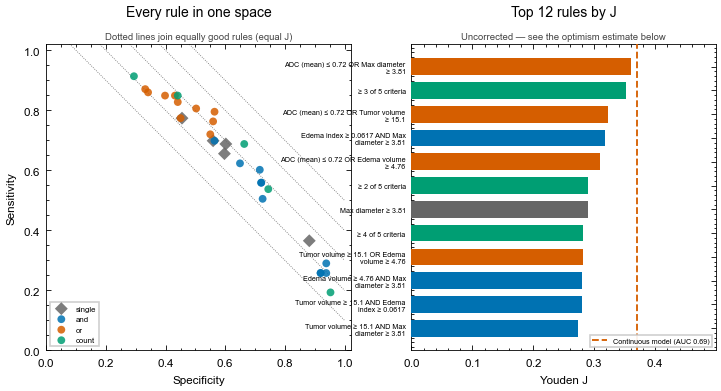

➖ Shared denominator (304 patients, every rule on the same people): best single becomes Max diameter ≥ 3.81 (corrected J 0.243); best combination ADC (mean) ≤ 0.72 OR Max diameter ≥ 3.81 (corrected J 0.323), gain +0.080, stable in 42% of resamples; uncut model J-equivalent 0.37. Reading: the combination now clears the effect-size bar (gain > 0.05) but not the stability one: the winner holds in 42% of resamples, so which combination is best is still mostly noise. The negative conclusion survives, on stability rather than on effect size.


In [26]:
SHARED = cb.shared_cohort(df, CUTPOINTS, TARGET)
print(f"Shared-denominator cohort: {len(SHARED)} of {len(df)} patients "
      f"({SHARED[TARGET].astype('boolean').sum()} high grade)")

SHARED_MENU = cb.full_rule_menu(SHARED, CUTPOINTS, TARGET)
art.table(SHARED_MENU, "30_shared_combination_menu",
          caption=f"Every rule, all scored on the same {len(SHARED)} patients")
art.table(cb.combination_reading_view(SHARED_MENU), "31_shared_combination_reading_view",
          formatted=False, caption="Shared-denominator rules ranked by Youden J")

SHARED_BENCHMARK = cb.continuous_model_benchmark(
    SHARED, METRICS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
SHARED_BEST_RULE = cb.bootstrap_best_rule(
    SHARED, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
SHARED_BEST_SINGLE = cb.bootstrap_best_rule(
    SHARED, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    kinds=("single",),
)
shared_auc = SHARED_BENCHMARK["AUC_corrected"]

SHARED_VERDICT = pd.DataFrame([{
    "cohort": "shared denominator (all four measured)",
    "n_used": len(SHARED),
    "best_single_rule": SHARED_BEST_SINGLE["best_rule"],
    "best_single_J": SHARED_BEST_SINGLE["J_apparent"],
    "best_single_J_corrected": SHARED_BEST_SINGLE["J_corrected"],
    "best_single_selection_optimism": SHARED_BEST_SINGLE["optimism"],
    "best_single_stability": SHARED_BEST_SINGLE["winner_stability"],
    "best_rule": SHARED_BEST_RULE["best_rule"],
    "best_rule_J": SHARED_BEST_RULE["J_apparent"],
    "best_rule_J_corrected": SHARED_BEST_RULE["J_corrected"],
    "selection_optimism": SHARED_BEST_RULE["optimism"],
    "winner_stability": SHARED_BEST_RULE["winner_stability"],
    "gain_apparent": SHARED_BEST_RULE["J_apparent"] - SHARED_BEST_SINGLE["J_apparent"],
    "gain_vs_best_single": SHARED_BEST_RULE["J_corrected"] - SHARED_BEST_SINGLE["J_corrected"],
    "continuous_AUC_corrected": shared_auc,
    "continuous_J_equivalent": 2.0 * (shared_auc - 0.5),
    "n_used_continuous": SHARED_BENCHMARK["n_used"],
}])
art.table(SHARED_VERDICT, "32_shared_combination_verdict",
          caption="Does combining help, with every rule on the same patients?")

art.figure(cb.combination_figure(SHARED_MENU, benchmark=SHARED_BENCHMARK),
           "33_shared_combination_space",
           caption=f"All rules on the same {len(SHARED)} patients, with the uncut benchmark")

# 🟧 The two bars a combination has to clear to count as helping. Both were
#    fixed before the shared-denominator run; neither is moved to fit it.
GAIN_BAR, STABILITY_BAR = 0.05, 0.50

shared_gain = float(SHARED_VERDICT["gain_vs_best_single"].iloc[0])
shared_stability = float(SHARED_VERDICT["winner_stability"].iloc[0])
clears_gain = shared_gain > GAIN_BAR
clears_stability = shared_stability > STABILITY_BAR

if clears_gain and clears_stability:
    reading = ("⚠️ the combination clears BOTH bars on one denominator — the earlier "
               "negative was partly a denominator artefact.")
elif clears_gain:
    reading = (f"the combination now clears the effect-size bar (gain > {GAIN_BAR}) but "
               f"not the stability one: the winner holds in {shared_stability * 100:.0f}% "
               f"of resamples, so which combination is best is still mostly noise. The "
               f"negative conclusion survives, on stability rather than on effect size.")
elif clears_stability:
    reading = ("the same rule wins reliably but the gain is too small to matter. The "
               "negative conclusion survives, on effect size rather than on stability.")
else:
    reading = "the combination clears neither bar. The negative conclusion survives intact."

shared_note = (
    f"Shared denominator ({len(SHARED)} patients, every rule on the same people): best "
    f"single becomes {SHARED_BEST_SINGLE['best_rule']} (corrected J "
    f"{SHARED_VERDICT['best_single_J_corrected'].iloc[0]:.3f}); best combination "
    f"{SHARED_BEST_RULE['best_rule']} (corrected J "
    f"{SHARED_VERDICT['best_rule_J_corrected'].iloc[0]:.3f}), gain {shared_gain:+.3f}, "
    f"stable in {shared_stability * 100:.0f}% of resamples; uncut model J-equivalent "
    f"{SHARED_VERDICT['continuous_J_equivalent'].iloc[0]:.2f}. Reading: {reading}"
)
print(("🎯 " if (clears_gain and clears_stability) else "➖ ") + shared_note)
art.note(shared_note)

### Calibration and net benefit

Everything above reports discrimination, which is blind to whether the probabilities are the right *size*. **Calibration** checks that; **net benefit** weighs a missed high-grade tumour against a false alarm across the risks at which you would act. Both on the shared denominator.

,model,n_used,events,n_predictors,slope_apparent,slope_corrected,intercept_apparent,intercept_corrected,brier_apparent,brier_corrected,n_bootstrap,source
0,Uncut 5-measurement model,304,93,5,1,0.876,0,0.003,0.189,0.197,1000,threshold phase (fitted here)
1,Cut 5-measurement model,304,93,5,1,0.914,0,-0.001,0.181,0.188,1000,threshold phase (fitted here)


💾 output/thresholds/tables/40_calibration.csv — 2 rows


,predicted,observed,lo,hi,n,events
0,0.101,0.129,0.051,0.289,31,4
1,0.147,0.100,0.035,0.256,30,3
2,0.177,0.133,0.053,0.297,30,4
3,0.215,0.161,0.071,0.326,31,5
4,0.264,0.300,0.167,0.479,30,9
5,0.309,0.400,0.246,0.577,30,12
6,0.355,0.355,0.211,0.531,31,11
7,0.410,0.400,0.246,0.577,30,12
8,0.491,0.533,0.361,0.698,30,16
9,0.589,0.548,0.378,0.708,31,17


💾 output/thresholds/tables/41_calibration_bins_uncut.csv — 10 rows


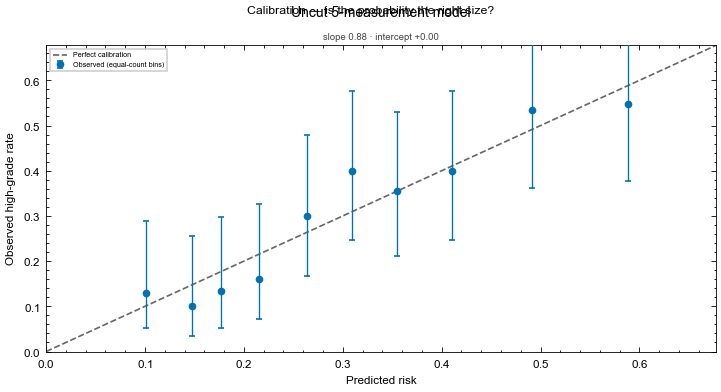

,strategy,threshold,net_benefit,kind
0,Treat all,0.05,0.269,reference
1,Treat none,0.05,0.000,reference
2,Best single cut-point (Max diameter ≥ 3.81),0.05,0.196,rule
3,Count score ≥ 1 of 5,0.05,0.254,rule
4,Count score ≥ 2 of 5,0.05,0.239,rule
...,...,...,...,...
555,Count score ≥ 3 of 5,0.60,-0.140,rule
556,Count score ≥ 4 of 5,0.60,-0.102,rule
557,Count score ≥ 5 of 5,0.60,0.010,rule
558,Uncut 5-measurement model,0.60,-0.002,model


💾 output/thresholds/tables/43_net_benefit.csv — 560 rows


,strategy,is_reference,max_net_benefit,threshold_at_max,beats_references_from,beats_references_to,pct_of_range_beating_references,pct_of_range_best_available,prevalence
0,Cut 5-measurement model,False,0.27,0.05,0.13,0.6,85.7,83.9,0.298
1,Count score ≥ 1 of 5,False,0.25,0.05,0.12,0.36,44.6,8.9,0.298
2,Uncut 5-measurement model,False,0.27,0.05,0.05,0.55,75.0,3.6,0.298
3,Count score ≥ 2 of 5,False,0.24,0.05,0.14,0.4,48.2,1.8,0.298
4,Count score ≥ 3 of 5,False,0.20,0.05,0.18,0.47,53.6,1.8,0.298
5,Best single cut-point (Max diameter ≥ 3.81),False,0.20,0.05,0.19,0.43,44.6,0.0,0.298
6,Count score ≥ 4 of 5,False,0.16,0.05,0.22,0.48,48.2,0.0,0.298
7,Count score ≥ 5 of 5,False,0.06,0.05,0.28,0.6,58.9,0.0,0.298
8,Treat all,True,0.27,0.05,,,0.0,0.0,0.298
9,Treat none,True,0.00,0.05,,,0.0,0.0,0.298


💾 output/thresholds/tables/44_net_benefit_summary.csv — 10 rows


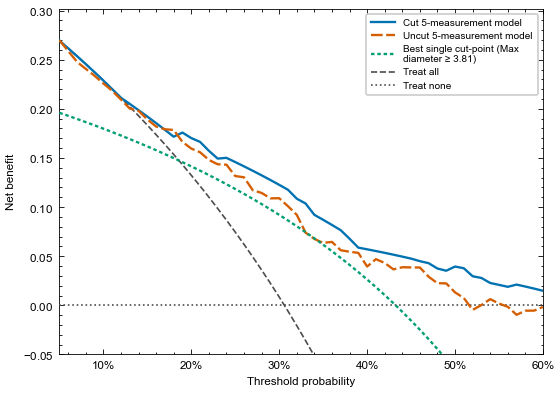

Cut 5-measurement model beats treat-all and treat-none from 13% to 60% threshold probability (86% of the plotted range), and is the best available strategy over 84% of it.
Count score ≥ 1 of 5 beats treat-all and treat-none from 12% to 36% threshold probability (45% of the plotted range), and is the best available strategy over 9% of it.
Uncut 5-measurement model beats treat-all and treat-none from 5% to 55% threshold probability (75% of the plotted range), and is the best available strategy over 4% of it.
Count score ≥ 2 of 5 beats treat-all and treat-none from 14% to 40% threshold probability (48% of the plotted range), and is the best available strategy over 2% of it.
Count score ≥ 3 of 5 beats treat-all and treat-none from 18% to 47% threshold probability (54% of the plotted range), and is the best available strategy over 2% of it.
Best single cut-point (Max diameter ≥ 3.81) beats treat-all and treat-none from 19% to 43% threshold probability (45% of the plotted range), and is the 

In [27]:
# 🟧 The range of "risk above which I would act" worth plotting. Anchored on the
#    cohort's own prevalence: below the base rate the sensible action is treat-all.
NET_BENEFIT_THRESHOLDS = cal.DEFAULT_THRESHOLDS
PREVALENCE = float(df[TARGET].astype("boolean").mean())

# ---- Calibration ---------------------------------------------------------
UNCUT_CALIBRATION = cal.uncut_model_calibration(
    SHARED, METRICS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
# The all-cut counterpart of the uncut model: same measurements, each one
# reduced to its yes/no flag, so the two rows differ only by the cutting.
CUT_CALIBRATION = cal.cut_model_calibration(
    SHARED, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
# Only the two models fitted here. The modelling phase's own artifacts are
# built on a different denominator and answer a different question.
CALIBRATION = pd.concat(
    [pd.DataFrame([UNCUT_CALIBRATION]), pd.DataFrame([CUT_CALIBRATION])],
    ignore_index=True,
)
art.table(CALIBRATION, "40_calibration",
          caption="Calibration slope and intercept, apparent and bootstrap-corrected")

y_uncut, p_uncut = cal.uncut_model_predictions(SHARED, METRICS, TARGET)
UNCUT_BINS = cal.calibration_bins(y_uncut, p_uncut)
# The model's own label carries the metric count, so nothing here says
# "four-measurement" after a fifth metric is added.
UNCUT_LABEL = UNCUT_CALIBRATION["model"]
art.table(UNCUT_BINS, "41_calibration_bins_uncut",
          caption=f"Observed vs predicted risk, {UNCUT_LABEL.lower()}")

panels = [(UNCUT_LABEL, UNCUT_BINS, UNCUT_CALIBRATION)]
art.figure(cal.calibration_figure(panels), "42_calibration",
           caption="Calibration of the uncut model")

# ---- Net benefit ---------------------------------------------------------
shared_flags = cb.flag_frame(SHARED, CUTPOINTS)
shared_counts, _ = cb.count_series(shared_flags)
best_single = SHARED_MENU.loc[
    SHARED_MENU.loc[SHARED_MENU["kind"] == "single", "youden_J"].idxmax()]
best_single_cp = next(cp for cp in CUTPOINTS if cp.label == best_single["rule_label"])

y_shared = SHARED[TARGET].astype("boolean").astype(bool).to_numpy()
STRATEGIES = {
    f"Best single cut-point ({best_single_cp.label})":
        best_single_cp.flag(SHARED).fillna(False).to_numpy(dtype=bool),
}
# Every rung of the count ladder, so nothing is hidden by picking two of them.
for _k in range(1, len(CUTPOINTS) + 1):
    STRATEGIES[f"Count score ≥ {_k} of {len(CUTPOINTS)}"] = (
        (shared_counts >= _k).fillna(False).to_numpy(dtype=bool))
if p_uncut.size == y_shared.size:
    STRATEGIES[UNCUT_LABEL] = p_uncut
_, p_cut = cal.cut_model_predictions(SHARED, CUTPOINTS, TARGET)
if p_cut.size == y_shared.size:
    STRATEGIES[CUT_CALIBRATION["model"]] = p_cut

NET_BENEFIT = cal.decision_curve(y_shared, STRATEGIES,
                                 thresholds=NET_BENEFIT_THRESHOLDS)
art.table(NET_BENEFIT, "43_net_benefit",
          caption="Net benefit of every strategy across the threshold range")

NET_BENEFIT_SUMMARY = cal.decision_curve_summary(NET_BENEFIT, prevalence=PREVALENCE)
art.table(NET_BENEFIT_SUMMARY, "44_net_benefit_summary",
          caption="Where each strategy beats treat-all / treat-none, and where it wins")

# 🟧 The curves the decision curve panel shows. Eight near-parallel lines are
#    unreadable at journal size, so the panel carries the two models and the
#    simple clinical baseline; every strategy stays in the tables above.
DCA_STRATEGIES = [
    CUT_CALIBRATION["model"],
    UNCUT_LABEL,
    f"Best single cut-point ({best_single_cp.label})",
]
art.figure(cal.decision_curve_figure(NET_BENEFIT, prevalence=PREVALENCE,
                                    strategies=DCA_STRATEGIES),
           "45_net_benefit",
           caption=f"Decision curve on the {len(SHARED)} shared-denominator patients")

for _, r in NET_BENEFIT_SUMMARY[~NET_BENEFIT_SUMMARY["is_reference"]].iterrows():
    if pd.isna(r["beats_references_from"]):
        note = (f"{r['strategy']} never beats treat-all or treat-none anywhere in the "
                f"{NET_BENEFIT_THRESHOLDS[0]:.0%}-{NET_BENEFIT_THRESHOLDS[-1]:.0%} "
                f"threshold range.")
    else:
        note = (f"{r['strategy']} beats treat-all and treat-none from "
                f"{r['beats_references_from']:.0%} to {r['beats_references_to']:.0%} "
                f"threshold probability ({r['pct_of_range_beating_references']:.0f}% of the "
                f"plotted range), and is the best available strategy over "
                f"{r['pct_of_range_best_available']:.0f}% of it.")
    print(note)
    art.note(note)

cal_note = (
    f"Uncut four-measurement model calibration: slope "
    f"{UNCUT_CALIBRATION['slope_apparent']:.2f} apparent, "
    f"{UNCUT_CALIBRATION['slope_corrected']:.2f} bootstrap-corrected; intercept "
    f"{UNCUT_CALIBRATION['intercept_apparent']:+.2f} apparent, "
    f"{UNCUT_CALIBRATION['intercept_corrected']:+.2f} corrected."
)
print(cal_note)
art.note(cal_note)

---
# 07. Does any of it survive the missing data?

Everything above is complete-case: 43 patients lack ADC, 23 tumor volume, 19 edema volume, and 48 lack at least one. If those patients differ, every answer above is shifted and **no bootstrap will show it** — resampling only re-draws the patients who are already there.

So the whole analysis is re-run inside each MICE draw.

In [28]:
MICE_DRAWS = st.load_imputed_draws(OUTPUT_ROOT, derive=derive_edema_index)
M_DRAWS = len(MICE_DRAWS)
print(f"Loaded {M_DRAWS} imputed draw(s) — {IMPUTATION_METHOD}")
if M_DRAWS < 2:
    print("⚠️ Only one frame: this is single imputation, so the spread below is not meaningful.")

Loaded 20 imputed draw(s) — mice


## 07a. Cut-points across the draws

`cutoff_mean` is the number to quote if you want one cut-point that used all 352 patients. **If mean and median disagree**, the `J` plateau is flat and the maximum is hopping between peaks — that is a finding, not a cut-point.

In [29]:
DRAW_TABLE = st.draw_cutoffs(MICE_DRAWS, METRICS, TARGET)
STABILITY_TABLE = st.imputation_stability(
    DRAW_TABLE, MICE_DRAWS, METRICS, TARGET, THRESHOLD_TABLE,
)
art.table(STABILITY_TABLE, "18_imputation_stability",
          caption="Across-draw cut-point summary next to the complete-case value")

art.table(st.stability_reading_view(STABILITY_TABLE), "19_imputation_stability_reading_view",
          formatted=False, caption="Complete-case vs MICE cut-points with both spreads")

,metric,column,rule,operator,m_draws,cutoff_mean,cutoff_median,cutoff_sd,cutoff_min,cutoff_max,cutoff_cv,sens_mean,spec_mean,J_mean,AUC_mean,sens_at_mean,spec_at_mean,cutoff_complete_case,cutoff_boot_lo,cutoff_boot_hi,n_complete_case,shift_vs_complete_case
0,ADC (mean),adc_value,closest_01,≤,20,0.79,0.79,0.01,0.76,0.79,0.01,0.53,0.65,0.17,0.63,0.49,0.69,0.790,0.730,0.848,309,-0.002
1,ADC (mean),adc_value,equal_sens_spec,≤,20,0.81,0.81,0.00,0.81,0.82,0.00,0.57,0.57,0.14,0.63,0.56,0.58,0.810,0.790,0.830,309,0.004
2,ADC (mean),adc_value,sens_ge_90,≤,20,1.00,1.00,0.01,1.00,1.05,0.01,0.91,0.15,0.06,0.63,0.91,0.16,1.000,0.920,1.150,309,0.004
3,ADC (mean),adc_value,spec_ge_90,≤,20,0.70,0.70,0.01,0.67,0.71,0.01,0.26,0.92,0.18,0.63,0.26,0.92,0.700,0.690,0.720,309,0.000
4,ADC (mean),adc_value,youden,≤,20,0.72,0.72,0.01,0.72,0.76,0.01,0.36,0.87,0.23,0.63,0.34,0.88,0.720,0.690,0.848,309,0.005
5,Edema index,edema_index,closest_01,≥,20,0.16,0.17,0.02,0.06,0.17,0.15,0.68,0.53,0.22,0.58,0.68,0.53,0.167,0.062,0.619,323,-0.005
6,Edema index,edema_index,equal_sens_spec,≥,20,0.27,0.28,0.02,0.23,0.29,0.06,0.57,0.57,0.15,0.58,0.57,0.58,0.339,0.191,0.494,323,-0.068
7,Edema index,edema_index,spec_ge_90,≥,20,3.85,3.89,0.22,3.70,4.68,0.06,0.05,0.91,-0.04,0.58,0.05,0.92,3.895,3.129,13.237,323,-0.049
8,Edema index,edema_index,youden,≥,20,0.06,0.06,0.00,0.05,0.06,0.05,0.76,0.48,0.24,0.58,0.76,0.48,0.062,0.043,0.175,323,-0.001
9,Edema volume,edema_volume_cm3,closest_01,≥,20,4.79,4.80,0.02,4.74,4.80,0.00,0.68,0.59,0.27,0.63,0.68,0.59,4.800,3.800,12.200,333,-0.005


💾 output/thresholds/tables/18_imputation_stability.csv — 23 rows


,Metric,Rule,Complete-case,Bootstrap 95%,MICE mean (m=20),MICE median,MICE SD,MICE range,Sens @ mean cut,Spec @ mean cut
0,ADC (mean),closest_01,≤0.79,0.73–0.848,≤0.788,≤0.79,0.00671,0.76–0.79,49%,69%
1,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,≤0.815,≤0.815,0.0032,0.81–0.82,56%,58%
2,ADC (mean),sens_ge_90,≤1,0.92–1.15,≤1,≤1,0.0139,1–1.05,91%,16%
3,ADC (mean),spec_ge_90,≤0.7,0.69–0.72,≤0.7,≤0.7,0.00826,0.67–0.71,26%,92%
4,ADC (mean),youden,≤0.72,0.69–0.848,≤0.725,≤0.72,0.00945,0.72–0.76,34%,88%
5,Edema index,closest_01,≥0.167,0.0617–0.619,≥0.162,≥0.167,0.0236,0.0617–0.167,68%,53%
6,Edema index,equal_sens_spec,≥0.339,0.191–0.494,≥0.271,≥0.281,0.017,0.232–0.286,57%,58%
7,Edema index,spec_ge_90,≥3.89,3.13–13.2,≥3.85,≥3.89,0.219,3.7–4.68,5%,92%
8,Edema index,youden,≥0.0617,0.0433–0.175,≥0.0606,≥0.0617,0.00318,0.0496–0.0617,76%,48%
9,Edema volume,closest_01,≥4.8,3.8–12.2,≥4.79,≥4.8,0.0157,4.74–4.8,68%,59%


💾 output/thresholds/tables/19_imputation_stability_reading_view.csv — 23 rows


,Metric,Rule,Complete-case,Bootstrap 95%,MICE mean (m=20),MICE median,MICE SD,MICE range,Sens @ mean cut,Spec @ mean cut
0,ADC (mean),closest_01,≤0.79,0.73–0.848,≤0.788,≤0.79,0.00671,0.76–0.79,49%,69%
1,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,≤0.815,≤0.815,0.0032,0.81–0.82,56%,58%
2,ADC (mean),sens_ge_90,≤1,0.92–1.15,≤1,≤1,0.0139,1–1.05,91%,16%
3,ADC (mean),spec_ge_90,≤0.7,0.69–0.72,≤0.7,≤0.7,0.00826,0.67–0.71,26%,92%
4,ADC (mean),youden,≤0.72,0.69–0.848,≤0.725,≤0.72,0.00945,0.72–0.76,34%,88%
5,Edema index,closest_01,≥0.167,0.0617–0.619,≥0.162,≥0.167,0.0236,0.0617–0.167,68%,53%
6,Edema index,equal_sens_spec,≥0.339,0.191–0.494,≥0.271,≥0.281,0.017,0.232–0.286,57%,58%
7,Edema index,spec_ge_90,≥3.89,3.13–13.2,≥3.85,≥3.89,0.219,3.7–4.68,5%,92%
8,Edema index,youden,≥0.0617,0.0433–0.175,≥0.0606,≥0.0617,0.00318,0.0496–0.0617,76%,48%
9,Edema volume,closest_01,≥4.8,3.8–12.2,≥4.79,≥4.8,0.0157,4.74–4.8,68%,59%


### The two instabilities, drawn

Shaded band: bootstrap (sampling noise). Dots: the MICE draws (missing-data uncertainty). Dots tight inside a wide band → sample size is the problem; dots scattered beyond it → the cut-point depends on the guessed values.

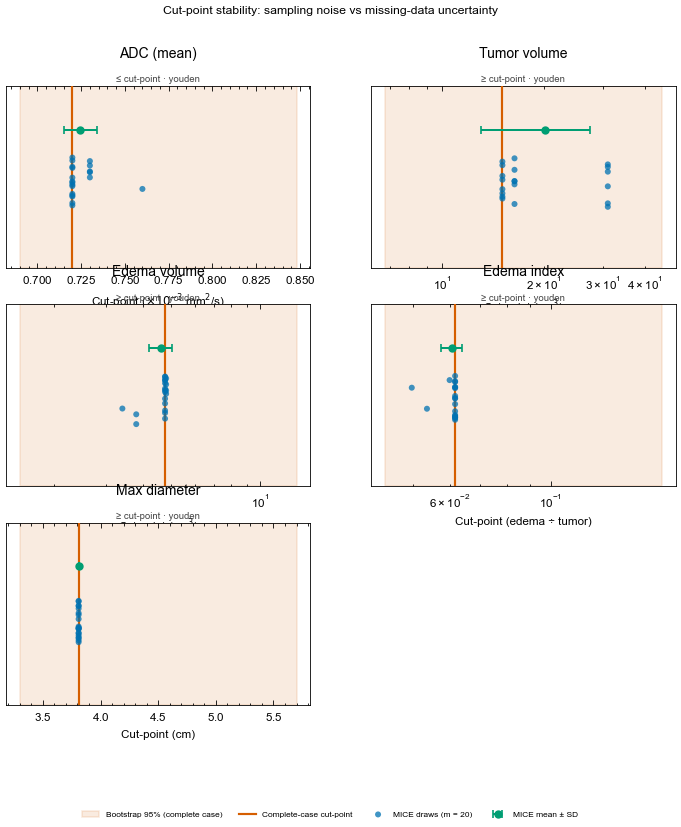

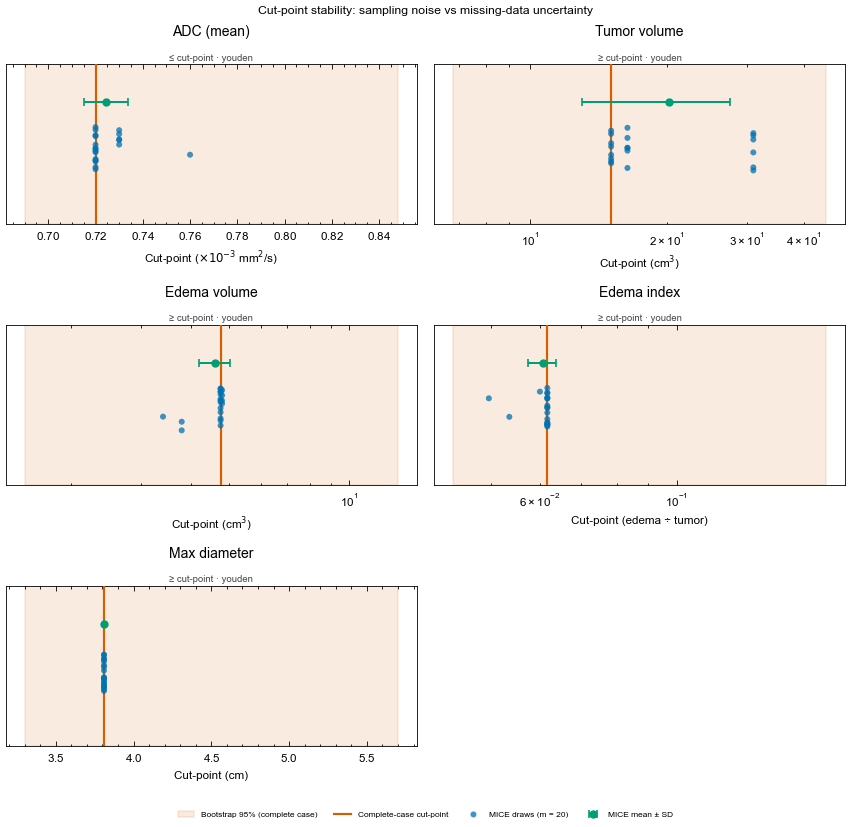

In [30]:
art.figure(st.stability_figure(DRAW_TABLE, STABILITY_TABLE, METRICS, rule="youden"),
           "20_stability_youden",
           caption="Sampling noise vs missing-data uncertainty in the Youden cut-point")

### Which number do I actually use?

Only three columns are candidate cut-points — complete-case, MICE mean, MICE median — the other three are error bars. Default to the complete-case value and report the MICE spread beside it; switch to the MICE mean only when the draws agree with each other and the complete-case value sits inside their range.

## 07b. Is the threshold reproducible?

`knee_rate` is the headline: the fraction of the imputed datasets in which an interior steepest point was found at all. An empty panel in the figure is a result, not a bug.

,metric,column,m_draws,nonlinear_rate,knee_rate,median_nonlinearity_p,AUC_mean,steepest_median,steepest_min,steepest_max,risk_30_median,risk_30_min,risk_30_max,risk_30_reached_rate,risk_50_median,risk_50_min,risk_50_max,risk_50_reached_rate
0,ADC (mean),adc_value,20,1.00,0.80,0.011,0.63,0.66,0.64,0.67,0.79,0.78,0.79,1,0.66,0.64,0.67,1
1,Tumor volume,tumor_volume,20,0.95,0.95,0.036,0.68,12.18,12.08,12.76,20.11,19.65,20.95,1,70.75,67.04,79.68,1
2,Edema volume,edema_volume_cm3,20,1.00,1.00,0.005,0.63,3.58,2.87,4.01,9.67,9.29,10.48,1,,,,0
3,Edema index,edema_index,20,0.90,0.90,0.028,0.58,0.09,0.08,0.11,0.42,0.38,0.47,1,,,,0
4,Max diameter,max_diameter_cm,20,0.00,0.00,0.503,0.67,,,,4.04,4.04,4.04,1,6.82,6.82,6.82,1


💾 output/thresholds/tables/21_risk_curve_stability.csv — 5 rows


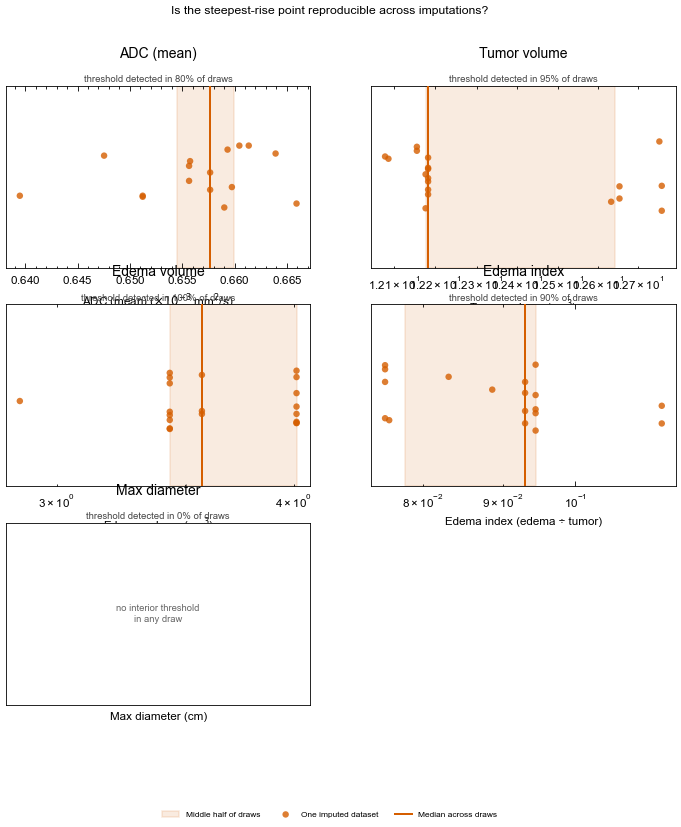

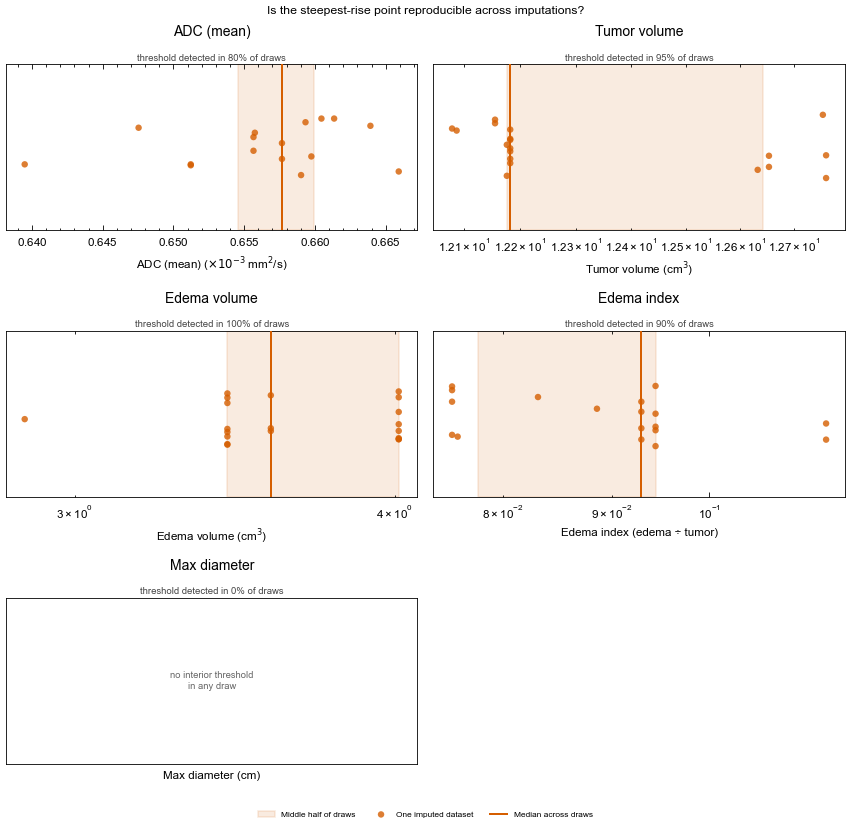

In [31]:
RISK_DRAWS = st.draw_risk_curves(MICE_DRAWS, METRICS, TARGET, risk_levels=RISK_LEVELS)
RISK_STABILITY = st.risk_curve_stability(RISK_DRAWS)
art.table(RISK_STABILITY, "21_risk_curve_stability",
          caption="How often each metric's threshold survives the imputation")

art.figure(st.knee_stability_figure(RISK_DRAWS, METRICS), "22_knee_stability",
           caption="Steepest-rise point across the MICE draws")

## 07c. The count score with every patient included

The complete-case count score drops 48 patients; inside a draw nothing is missing, so everyone gets a count. `risk_min` / `risk_max` are the range across the draws.

,n_criteria_met,n,n_high_grade,risk,risk_min,risk_max,risk_lo,risk_hi
0,0,85,10,0.116,0.10,0.13,0.064,0.202
1,1,43,7,0.154,0.12,0.19,0.075,0.290
2,2,72,17,0.236,0.22,0.26,0.153,0.345
3,3,38,16,0.415,0.38,0.44,0.272,0.572
4,4,84,36,0.432,0.40,0.45,0.332,0.539
5,5,30,19,0.647,0.60,0.68,0.468,0.792


💾 output/thresholds/tables/23_count_score_imputed.csv — 6 rows


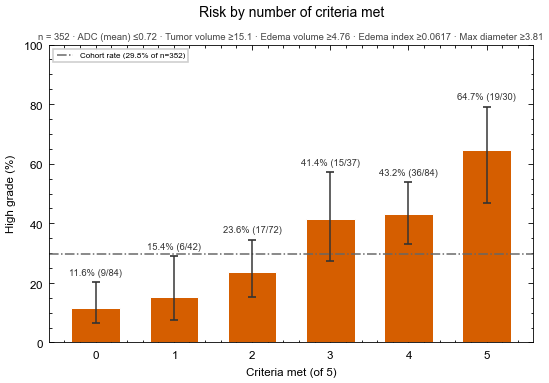

,rule_label,n_used,sensitivity,sens_min,sens_max,specificity,spec_min,spec_max,PPV,NPV,youden_J,J_min,J_max
0,≥ 1 of 5 criteria,352,0.906,0.90,0.91,0.303,0.29,0.31,0.356,0.884,0.209,0.19,0.23
1,≥ 2 of 5 criteria,352,0.843,0.84,0.85,0.450,0.44,0.46,0.395,0.871,0.293,0.28,0.31
2,≥ 3 of 5 criteria,352,0.681,0.67,0.70,0.674,0.66,0.69,0.470,0.832,0.355,0.33,0.38
3,≥ 4 of 5 criteria,352,0.532,0.50,0.54,0.763,0.75,0.77,0.489,0.793,0.295,0.26,0.32
4,≥ 5 of 5 criteria,352,0.185,0.17,0.20,0.957,0.95,0.96,0.647,0.734,0.142,0.12,0.16


💾 output/thresholds/tables/25_count_rules_imputed.csv — 5 rows


,rule_label,n_used,sensitivity,sens_min,sens_max,specificity,spec_min,spec_max,PPV,NPV,youden_J,J_min,J_max
0,≥ 1 of 5 criteria,352.0,0.906190,0.895238,0.914286,0.303036,0.287449,0.311741,0.355973,0.883706,0.209227,0.190785,0.226027
1,≥ 2 of 5 criteria,352.0,0.843333,0.838095,0.847619,0.450000,0.437247,0.461538,0.394623,0.871081,0.293333,0.279391,0.305109
2,≥ 3 of 5 criteria,352.0,0.680952,0.666667,0.695238,0.673684,0.659919,0.688259,0.470149,0.832402,0.354637,0.330634,0.383497
3,≥ 4 of 5 criteria,352.0,0.531905,0.504762,0.542857,0.763360,0.753036,0.773279,0.488659,0.793231,0.295265,0.257798,0.316136
4,≥ 5 of 5 criteria,352.0,0.184762,0.171429,0.200000,0.957085,0.951417,0.959514,0.646516,0.734167,0.141847,0.122846,0.159514


In [32]:
COUNT_DRAWS = st.draw_count_scores(MICE_DRAWS, CUTPOINTS, TARGET)
art.table(COUNT_DRAWS, "23_count_score_imputed",
          caption=f"Count-score risk averaged over {M_DRAWS} MICE draws (all patients)")

art.figure(
    cb.count_score_figure(COUNT_DRAWS, cutpoints=CUTPOINTS,
                          prevalence=float(df[TARGET].astype("boolean").mean())),
    "24_count_score_imputed",
    caption=f"Risk by criteria met, averaged over {M_DRAWS} MICE draws",
)

art.table(st.draw_count_rules(MICE_DRAWS, CUTPOINTS, TARGET), "25_count_rules_imputed",
          caption='"≥ k criteria" rules scored inside every draw')

---
# 08. How strong is each threshold claim?

A bare "yes" from one p-value is a weak claim and an easy one to attack. Each threshold is graded against **five criteria fixed before any verdict was read**: real bend, knee inside the data, knee distinct from the 50%-risk crossing, robust to a log scale, reproducible across the draws.

Grades: strong / moderate / fragile / weak.

In [33]:
EVIDENCE = ev.threshold_evidence(
    RISK_TABLE, RISK_STABILITY,
    # Non-scoring context: the zero-inflation refit from §04. It does not move
    # the grade — it was not one of the five pre-specified criteria — but a
    # curvature that vanishes on the non-zero subset changes what the knee means.
    positive_risk_table=POSITIVE_RISK_TABLE,
    zero_share_table=ZERO_SHARE,
)

art.table(ev.criteria_table(), "27_evidence_criteria", formatted=False,
          caption="The five pre-specified criteria and the rule each applies")
art.table(EVIDENCE, "28_threshold_evidence",
          caption="Each metric scored on the five criteria, with its graded verdict")
art.table(ev.evidence_reading_view(EVIDENCE), "29_threshold_evidence_reading_view",
          formatted=False, caption="The graded verdict, in reading order")

MARK = {"strong": "🟩", "moderate": "🟨", "fragile": "🟧", "weak": "🟥"}
for _, row in EVIDENCE.iterrows():
    print(f"{MARK[row['verdict']]} {row['metric']}: {row['verdict_note']}")
    art.note(f"{row['metric']} — threshold evidence {row['verdict_note']}.")

,Criterion,Family,Source,Rule
0,Non-linearity,necessary,"Likelihood-ratio test, spline vs straight line...",p &lt; 0.05
1,Knee interiority,necessary,Percentile of patients below the steepest poin...,≥ 5% of patients on each side
2,Knee ≠ 50%-risk point,necessary,Bootstrap interval of the 50% risk crossing (s...,steepest point falls outside that interval
3,Scale robustness,robustness,<code>nonlinearity_p_log_scale</code> (section 3),non-linear on the clinical scale <b>and</b> on...
4,MICE reproducibility,robustness,<code>knee_rate</code> across the imputed data...,knee found again in ≥ 80% of draws


💾 output/thresholds/tables/27_evidence_criteria.csv — 5 rows


,metric,column,verdict,n_criteria_passed,n_criteria,limiting_criterion,failed_criteria,knee_ci_ratio,AUC,pct_zero,nonlinearity_p_nonzero_only,knee_found_nonzero_only,pass_nonlinearity,detail_nonlinearity,pass_interiority,detail_interiority,pass_distinct_from_50,detail_distinct_from_50,pass_scale_robust,detail_scale_robust,pass_mice_reproducible,detail_mice_reproducible,verdict_note,context_note
0,ADC (mean),adc_value,fragile,4,5,Knee ≠ 50%-risk point,Knee ≠ 50%-risk point,1.120,0.63,,,,True,p = 0.009 on the clinical scale,True,7% of patients below the knee,False,knee 0.662 vs 50% crossing CI 0.597–0.713 — in...,True,log-scale p = 0.015,True,knee found in 80% of draws,fragile — Knee ≠ 50%-risk point fails (knee 0....,
1,Tumor volume,tumor_volume,moderate,4,5,Scale robustness,Scale robustness,1.772,0.68,,,,True,p = 0.021 on the clinical scale,True,47% of patients below the knee,True,knee 12.7 vs 50% crossing CI 32–102 — outside it,False,log-scale p = 0.974,True,knee found in 95% of draws,moderate — Scale robustness fails (log-scale p...,
2,Edema volume,edema_volume_cm3,moderate,4,5,Scale robustness,Scale robustness,4.476,0.63,36.6,0.18,False,True,p = 0.007 on the clinical scale,True,48% of patients below the knee,True,"50% risk located in only 28% of resamples, so ...",False,log-scale p = 0.159,True,knee found in 100% of draws,moderate — Scale robustness fails (log-scale p...,36.6% of measured patients are exactly zero; r...
3,Edema index,edema_index,strong,5,5,,,3.907,0.58,35.0,0.675,False,True,p = 0.047 on the clinical scale,True,41% of patients below the knee,True,"50% risk located in only 6% of resamples, so t...",True,log-scale p = 0.002,True,knee found in 90% of draws,strong — all 5 criteria met,35.0% of measured patients are exactly zero; r...
4,Max diameter,max_diameter_cm,weak,2,5,Non-linearity,Non-linearity; Scale robustness; MICE reproduc...,2.152,0.67,,,,False,p = 0.503 on the clinical scale,True,46% of patients below the knee,True,knee 3.56 vs 50% crossing CI 5.66–7.66 — outsi...,False,log-scale p = 0.773,False,knee found in 0% of draws,weak — Non-linearity fails (p = 0.503 on the c...,


💾 output/thresholds/tables/28_threshold_evidence.csv — 5 rows


,Metric,Evidence,Non-linearity,Knee interiority,Knee ≠ 50%-risk point,Scale robustness,MICE reproducibility,Criteria met,What limits it,Read alongside (does not score)
0,ADC (mean),fragile,pass — p = 0.009 on the clinical scale,pass — 7% of patients below the knee,fail — knee 0.662 vs 50% crossing CI 0.597–0.7...,pass — log-scale p = 0.015,pass — knee found in 80% of draws,4 of 5,Knee ≠ 50%-risk point,—
1,Tumor volume,moderate,pass — p = 0.021 on the clinical scale,pass — 47% of patients below the knee,pass — knee 12.7 vs 50% crossing CI 32–102 — o...,fail — log-scale p = 0.974,pass — knee found in 95% of draws,4 of 5,Scale robustness,—
2,Edema volume,moderate,pass — p = 0.007 on the clinical scale,pass — 48% of patients below the knee,pass — 50% risk located in only 28% of resampl...,fail — log-scale p = 0.159,pass — knee found in 100% of draws,4 of 5,Scale robustness,36.6% of measured patients are exactly zero; r...
3,Edema index,strong,pass — p = 0.047 on the clinical scale,pass — 41% of patients below the knee,pass — 50% risk located in only 6% of resample...,pass — log-scale p = 0.002,pass — knee found in 90% of draws,5 of 5,—,35.0% of measured patients are exactly zero; r...
4,Max diameter,weak,fail — p = 0.503 on the clinical scale,pass — 46% of patients below the knee,pass — knee 3.56 vs 50% crossing CI 5.66–7.66 ...,fail — log-scale p = 0.773,fail — knee found in 0% of draws,2 of 5,Non-linearity,—


💾 output/thresholds/tables/29_threshold_evidence_reading_view.csv — 5 rows
🟧 ADC (mean): fragile — Knee ≠ 50%-risk point fails (knee 0.662 vs 50% crossing CI 0.597–0.713 — inside it)
🟨 Tumor volume: moderate — Scale robustness fails (log-scale p = 0.974)
🟨 Edema volume: moderate — Scale robustness fails (log-scale p = 0.159)
🟩 Edema index: strong — all 5 criteria met
🟥 Max diameter: weak — Non-linearity fails (p = 0.503 on the clinical scale); Scale robustness fails (log-scale p = 0.773); MICE reproducibility fails (knee found in 0% of draws)


---
# 09. Headline findings

One row per metric: does it discriminate, does it have a threshold, is that threshold reproducible, and what cut-point would you quote.

In [34]:
def headline_rows() -> pd.DataFrame:
    risk = RISK_TABLE.set_index("column")
    risk_stab = RISK_STABILITY.set_index("column")
    stab = STABILITY_TABLE[STABILITY_TABLE["rule"] == "youden"].set_index("column")
    evid = EVIDENCE.set_index("column")
    youden = THRESHOLD_TABLE[THRESHOLD_TABLE["rule"] == "youden"].set_index("column")

    rows = []
    for metric in METRICS:
        col = metric.col
        r, y = risk.loc[col], youden.loc[col]
        s = stab.loc[col] if col in stab.index else None
        rs = risk_stab.loc[col] if col in risk_stab.index else None
        rows.append({
            "Metric": metric.label,
            "Unit": metric.prose_unit,
            "n": int(r["n"]),
            "AUC": round(float(r["AUC"]), 2),
            # Graded, not yes/no (§08). A bare "yes" hides the difference
            # between a knee sitting in the bulk of the cohort and one that is
            # the 50%-risk crossing renamed — and both used to print as "yes".
            "Threshold evidence": evid.loc[col, "verdict"],
            "What limits it": evid.loc[col, "limiting_criterion"] or "—",
            "Non-linearity p": ps.format_p(r["nonlinearity_p"]),
            "Steepest rise": ("—" if not r["knee_found"]
                              else f"{r['steepest_x']:.3g} ({r['steepest_lo']:.3g}–{r['steepest_hi']:.3g})"),
            "Reproducible (MICE)": ("" if rs is None
                                    else f"{rs['knee_rate'] * 100:.0f}% of draws"),
            "Risk 30% at": ("never" if pd.isna(r["risk_30_x"]) else f"{metric.op}{r['risk_30_x']:.3g}"),
            "Risk 50% at": ("never" if pd.isna(r["risk_50_x"]) else f"{metric.op}{r['risk_50_x']:.3g}"),
            "Youden cut-point": f"{metric.op}{y['cutoff']:.3g}",
            "Cut-point 95% CI": f"{y['cutoff_boot_lo']:.3g}–{y['cutoff_boot_hi']:.3g}",
            "Sens / Spec": f"{y['sensitivity'] * 100:.0f}% / {y['specificity'] * 100:.0f}%",
            "J (corr.)": round(float(y["youden_J_corrected"]), 2),
            "MICE cut-point": "" if s is None else f"{metric.op}{s['cutoff_mean']:.3g}",
            "Cut-point stable?": ("" if s is None else
                                  ("yes" if abs(s["cutoff_mean"] - s["cutoff_median"])
                                   <= 0.1 * abs(s["cutoff_median"]) else "no — mean ≠ median")),
        })
    return pd.DataFrame(rows)


HEADLINE = headline_rows()
art.table(HEADLINE, "26_headline_findings", formatted=False,
          caption="One row per metric: discrimination, threshold, reproducibility, cut-point")

,Metric,Unit,n,AUC,Threshold evidence,What limits it,Non-linearity p,Steepest rise,Reproducible (MICE),Risk 30% at,Risk 50% at,Youden cut-point,Cut-point 95% CI,Sens / Spec,J (corr.),MICE cut-point,Cut-point stable?
0,ADC (mean),×10⁻³ mm²/s,309,0.63,fragile,Knee ≠ 50%-risk point,= 0.009,0.662 (0.628–0.704),80% of draws,≤0.791,≤0.663,≤0.72,0.69–0.848,35% / 88%,0.21,≤0.725,yes
1,Tumor volume,cm³,329,0.68,moderate,Scale robustness,= 0.021,12.7 (9.71–17.2),95% of draws,≥18.5,≥62.3,≥15.1,6.78–44.8,67% / 60%,0.23,≥20.3,no — mean ≠ median
2,Edema volume,cm³,333,0.63,moderate,Scale robustness,= 0.007,3.51 (1.62–7.23),100% of draws,≥9.92,never,≥4.76,1.53–13.3,69% / 59%,0.25,≥4.6,yes
3,Edema index,,323,0.58,strong,—,= 0.047,0.0915 (0.0657–0.257),90% of draws,≥0.383,never,≥0.0617,0.0433–0.175,77% / 46%,0.21,≥0.0606,yes
4,Max diameter,cm,352,0.67,weak,Non-linearity,= 0.503,—,0% of draws,≥4.04,≥6.82,≥3.81,3.3–5.7,69% / 60%,0.25,≥3.81,yes


💾 output/thresholds/tables/26_headline_findings.csv — 5 rows


,Metric,Unit,n,AUC,Threshold evidence,What limits it,Non-linearity p,Steepest rise,Reproducible (MICE),Risk 30% at,Risk 50% at,Youden cut-point,Cut-point 95% CI,Sens / Spec,J (corr.),MICE cut-point,Cut-point stable?
0,ADC (mean),×10⁻³ mm²/s,309,0.63,fragile,Knee ≠ 50%-risk point,= 0.009,0.662 (0.628–0.704),80% of draws,≤0.791,≤0.663,≤0.72,0.69–0.848,35% / 88%,0.21,≤0.725,yes
1,Tumor volume,cm³,329,0.68,moderate,Scale robustness,= 0.021,12.7 (9.71–17.2),95% of draws,≥18.5,≥62.3,≥15.1,6.78–44.8,67% / 60%,0.23,≥20.3,no — mean ≠ median
2,Edema volume,cm³,333,0.63,moderate,Scale robustness,= 0.007,3.51 (1.62–7.23),100% of draws,≥9.92,never,≥4.76,1.53–13.3,69% / 59%,0.25,≥4.6,yes
3,Edema index,,323,0.58,strong,—,= 0.047,0.0915 (0.0657–0.257),90% of draws,≥0.383,never,≥0.0617,0.0433–0.175,77% / 46%,0.21,≥0.0606,yes
4,Max diameter,cm,352,0.67,weak,Non-linearity,= 0.503,—,0% of draws,≥4.04,≥6.82,≥3.81,3.3–5.7,69% / 60%,0.25,≥3.81,yes


### The sentences these numbers support

Templates filled from the table above. Drafting aids — check each against the figures before it goes near a manuscript.

In [35]:
for metric in METRICS:
    curve = CURVES[metric.col]
    row = RISK_TABLE.set_index("column").loc[metric.col]
    y = THRESHOLD_TABLE[
        (THRESHOLD_TABLE["column"] == metric.col) & (THRESHOLD_TABLE["rule"] == "youden")
    ].iloc[0]
    stab = RISK_STABILITY.set_index("column").loc[metric.col]

    unit = f" {metric.prose_unit}" if metric.prose_unit else ""
    p_text = f"likelihood-ratio test for non-linearity p {ps.format_p(row['nonlinearity_p'])}"

    grade = EVIDENCE.set_index("column").loc[metric.col]

    print(f"\n▪ {metric.label}")
    print(f"   Threshold evidence: {grade['verdict_note']}.")
    if curve.knee_found:
        print(f"   Risk of high-grade meningioma rose non-linearly with {metric.label} "
              f"({p_text}), with the steepest increase at {row['steepest_x']:.3g}{unit} "
              f"(95% CI {row['steepest_lo']:.3g}–{row['steepest_hi']:.3g}); this threshold was "
              f"reproduced in {stab['knee_rate'] * 100:.0f}% of {M_DRAWS} imputed datasets.")
    elif curve.nonlinear:
        # Curved, but still climbing (or already flat) where the data stop —
        # calling this "no evidence of non-linearity" would misreport the test.
        print(f"   The relationship between {metric.label} and risk of high-grade "
              f"meningioma was non-linear ({p_text}), but risk rose fastest at the edge "
              f"of the observed range, so no threshold could be located within it.")
    else:
        print(f"   Risk of high-grade meningioma increased monotonically with {metric.label} "
              f"with no evidence of a threshold effect ({p_text}).")
    if pd.notna(row["risk_50_x"]):
        print(f"   Predicted risk exceeded 50% at {metric.label} {metric.op} "
              f"{row['risk_50_x']:.3g}{unit}.")
    elif pd.notna(row["risk_30_x"]):
        print(f"   Predicted risk exceeded 30% at {metric.label} {metric.op} "
              f"{row['risk_30_x']:.3g}{unit} but never reached 50%.")
    print(f"   The optimal cut-point by Youden's index was {metric.op}{y['cutoff']:.3g} "
          f"(bootstrap 95% CI {y['cutoff_boot_lo']:.3g}–{y['cutoff_boot_hi']:.3g}), "
          f"sensitivity {y['sensitivity'] * 100:.0f}% "
          f"({y['sensitivity_lo'] * 100:.0f}–{y['sensitivity_hi'] * 100:.0f}), "
          f"specificity {y['specificity'] * 100:.0f}% "
          f"({y['specificity_lo'] * 100:.0f}–{y['specificity_hi'] * 100:.0f}); "
          f"optimism-corrected J {y['youden_J_corrected']:.2f}.")


▪ ADC (mean)
   Threshold evidence: fragile — Knee ≠ 50%-risk point fails (knee 0.662 vs 50% crossing CI 0.597–0.713 — inside it).
   Risk of high-grade meningioma rose non-linearly with ADC (mean) (likelihood-ratio test for non-linearity p = 0.009), with the steepest increase at 0.662 ×10⁻³ mm²/s (95% CI 0.628–0.704); this threshold was reproduced in 80% of 20 imputed datasets.
   Predicted risk exceeded 50% at ADC (mean) ≤ 0.663 ×10⁻³ mm²/s.
   The optimal cut-point by Youden's index was ≤0.72 (bootstrap 95% CI 0.69–0.848), sensitivity 35% (27–45), specificity 88% (83–92); optimism-corrected J 0.21.

▪ Tumor volume
   Threshold evidence: moderate — Scale robustness fails (log-scale p = 0.974).
   Risk of high-grade meningioma rose non-linearly with Tumor volume (likelihood-ratio test for non-linearity p = 0.021), with the steepest increase at 12.7 cm³ (95% CI 9.71–17.2); this threshold was reproduced in 95% of 20 imputed datasets.
   Predicted risk exceeded 50% at Tumor volume ≥ 62.

---
# 10. Before any of this goes in a paper

- Every data-derived cut-point here is optimistic; quote `youden_J_corrected` beside `youden_J`, or validate an external cut-point instead.
- Where a bootstrap interval spans an order of magnitude, the defensible sentence is that **no stable cut-point exists in this cohort**.
- PPV and NPV do not transfer out of a surgical series; sensitivity and specificity do.
- The MICE draws are a stability check, not Rubin pooling — the spread is a range, not a confidence interval.

---
## 11. Build `threshold_report.html`

Assembled from the tables and figures this run just wrote — nothing is refitted, so the report and the CSVs cannot disagree.

Seven questions, each with a two-sentence method note, one figure, one table and one answer; then a copy-paste abstract block and the list of clinical facts only you can supply.

In [36]:
# Write the manifest before building the report — the report reads it
# back from disk, so this has to reflect this run, not the previous one.
manifest_path = art.write_manifest()

import threshold_report as trep

# 🟧 Goes on the title page.
REPORT_AUTHOR = ""

report_cfg = trep.ThresholdReportConfig(
    output_root=OUTPUT_ROOT,
    author=REPORT_AUTHOR,
)
report_data = trep.load_report_data(report_cfg)
report_path = trep.write_html(
    trep.build_report(report_cfg, report_data), report_cfg.default_out,
)
print(f"📄 {report_path}")
for warning in report_data.warnings:
    print(f"   ⚠️ {warning}")

# The open methods questions, repeated here so they are the last thing the run
# prints rather than something to hunt for in the HTML.
still_open = study.open_questions(report_data.table("study_facts"))
if len(still_open):
    print(f"\n🟧 {len(still_open)} open question(s) in §9 — answer them in STUDY_FACTS:")
    for _, row in still_open.iterrows():
        print(f"   • {row['item']} — {row['answer']}")

📄 /Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/output/thresholds/threshold_report.html

🟧 4 open question(s) in §9 — answer them in STUDY_FACTS:
   • Who read the histology, and were they blinded — How many pathologists reported the grade, and whether they saw the MRI.
   • DWI acquisition — Field strength, scanner, and the b-values the ADC maps were computed from. Note any scanner or protocol change during accrual.
   • How the ADC ROI was placed — Whole-tumour or single-slice; solid portion only or whole mass; how many readers, and whether they knew the grade.
   • How the volumes were measured — Manual, semi-automated or automated; the software and version; on which sequence; by whom.


## 12. Export receipt

Everything this run wrote, plus `manifest.json` with the settings that produced it. Leftovers from a previous configuration are listed, not deleted.

In [37]:
receipt = art.written()
print(f"{len(receipt)} artifacts under {art.root}")
if manifest_path:
    print(f"📄 {manifest_path}")

stale = art.stale_files()
if stale:
    print(f"\n⚠️ {len(stale)} file(s) in the output folder were not written by this run:")
    for path in stale:
        print(f"   {path}")

receipt

62 artifacts under output/thresholds
📄 output/thresholds/manifest.json


,kind,name,rows,caption,path
0,table,47_literature_sources.csv,9.0,"Published cut-points scored on this cohort, wi...",output/thresholds/tables/47_literature_sources...
1,table,46_study_facts.csv,8.0,"Methods facts: read from the cleaning run, or ...",output/thresholds/tables/46_study_facts.csv
2,table,00_cohort_summary.csv,1.0,"Patients, events and prevalence for the whole ...",output/thresholds/tables/00_cohort_summary.csv
3,table,01_metric_cohorts.csv,5.0,Complete-case count and class balance per metric,output/thresholds/tables/01_metric_cohorts.csv
4,figure,02_distribution_adc_value.svg,NaN,ADC (mean) by WHO grade,output/thresholds/figures/02_distribution_adc_...
...,...,...,...,...,...
57,table,25_count_rules_imputed.csv,5.0,"""≥ k criteria"" rules scored inside every draw",output/thresholds/tables/25_count_rules_impute...
58,table,27_evidence_criteria.csv,5.0,The five pre-specified criteria and the rule e...,output/thresholds/tables/27_evidence_criteria.csv
59,table,28_threshold_evidence.csv,5.0,"Each metric scored on the five criteria, with ...",output/thresholds/tables/28_threshold_evidence...
60,table,29_threshold_evidence_reading_view.csv,5.0,"The graded verdict, in reading order",output/thresholds/tables/29_threshold_evidence...
